# Goal

The objective here was to predict the squared amplitude (`sq_amp`) from the corresponding interaction topology(feynman diagram) and amplitude representation.

Unlike regular sequence-to-sequence NLP tasks that we are used to, symbolic physics prediction requires simultaneously learning:
- algebraic structure from mathematical expressions
- relational structure from Feynman interaction graphs

A naive approach of directly concatenating these representations would force the model to implicitly learn structural distinctions on its own, which becomes highly inefficient in low-data scientific settings.(which is usually the case in real life settings)

Not to mention that the representation of the interaction diagram and the amplitudes prior to tokenization must be well thought of to preseve the relational information and maintain a non abmbigiuous 1 to 1 mapping.

The primary goal of the baseline architecture was therefore to:
1. preserve graph and algebraic structure independently,
2. investigate how each modality contributes to prediction quality,
3. and establish whether structure-aware modeling improves symbolic physics prediction.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



# Dataset Description

The dataset consists entirely of symbolic \(2 \rightarrow 2\) particle interaction processes from two different physical domains:

1. **QED (Quantum Electrodynamics)**  
   - Samples generated from tree level 0 up to tree level 9

2. **QCD (Quantum Chromodynamics)**  
   - Samples generated from tree level 0 up to tree level 6

Each dataset file contains multiple interaction samples stored as structured symbolic expressions.

Every sample is represented using four components separated by whitespace delimiters:

```text
interaction  :  vertices  :  amp  :  sq_amp

In [ ]:

# DATA EXTRACTION & SPLITTING
import os
from google.colab import drive
from sklearn.model_selection import train_test_split

# Config
DRIVE_FOLDER   = '/content/drive/MyDrive/Symba'
TEST_SIZE      = 0.1
RANDOM_STATE   = 42

drive.mount('/content/drive')

def robust_splitter(line): #basically splitting data into amp ,sq_amp and feynman diagram (vertices and interaction)
    """
    Splits a raw data line into its 4 components on the ' : ' delimiter.
    Returns (None, None, None, None) if the line is malformed.
    """
    parts = line.split(" : ")
    if len(parts) == 4:
        return tuple(p.strip() for p in parts)
    return None, None, None, None


def build_structured_datasets(data_directory):
    """
    Walks `data_directory`, reads every .txt file, and routes each
    valid data point into qed_dataset or qcd_dataset based on filename.
    """
    qed_dataset, qcd_dataset = [], []

    if not os.path.exists(data_directory):
        print(f"[ERROR] Folder not found: '{data_directory}'")
        return qed_dataset, qcd_dataset

    print(f"Scanning: {data_directory} ...")

    for filename in os.listdir(data_directory):
        if not filename.endswith(".txt"):
            continue

        filepath = os.path.join(data_directory, filename)
        tag = filename.upper()

        with open(filepath, 'r', encoding='utf-8') as fh:
            for line in fh:
                if not line.strip():
                    continue

                interaction, vertices, amp, sq_amp = robust_splitter(line)
                if not all([amp, sq_amp, vertices]):
                    continue

                record = {
                    "interaction" : interaction,
                    "vertices"    : vertices,
                    "amp"         : amp,
                    "sq_amp"      : sq_amp,
                    "source_file" : filename,
                }

                if "QED" in tag:
                    qed_dataset.append(record)
                elif "QCD" in tag:
                    qcd_dataset.append(record)
                else:
                    print(f"[WARN] Cannot classify '{filename}' as QED or QCD — skipping.")

    return qed_dataset, qcd_dataset


# Extraction
qed_data, qcd_data = build_structured_datasets(DRIVE_FOLDER)
print(f"QED diagrams extracted : {len(qed_data)}")
print(f"QCD diagrams extracted : {len(qcd_data)}")

# 90/10 Split
qed_train = qed_test = qcd_train = qcd_test = []

if qed_data:
    qed_train, qed_test = train_test_split(
        qed_data, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"QED split → {len(qed_train)} train | {len(qed_test)} test")

if qcd_data:
    qcd_train, qcd_test = train_test_split(
        qcd_data, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"QCD split → {len(qcd_train)} train | {len(qcd_test)} test")

Mounted at /content/drive
Scanning: /content/drive/MyDrive/Symba ...
QED diagrams extracted : 360
QCD diagrams extracted : 234
QED split → 324 train | 36 test
QCD split → 210 train | 24 test


In [ ]:

#DATA CLEANING (GRAPH & MATH)
import re

def perfect_standardizer(expression: str) -> str:
    r"""
    Abstracts dummy indices without touching physical kinematics.
    Example: %\mu_99 -> %\mu_d1
    """
    mapping      = {}
    counter      = [1]                          # list so nested fn can mutate it

    def replacer(match):
        prefix    = match.group(1)
        index_str = match.group(2)
        if index_str not in mapping:
            mapping[index_str] = f"d{counter[0]}"
            counter[0] += 1
        return f"{prefix}{mapping[index_str]}"

    return re.sub(r'(%[a-zA-Z\\]+_)(\d+)', replacer, expression)


def clean_graph_topology(text: str) -> str:
    r"""
    Strips redundant English keywords from interaction/vertex strings.
    Leaves all numbers intact for downstream digit-wise tokenization.
    """
    text = text.replace("Interaction:", "").replace("Vertex ", "").replace("Vertex", "")
    return " ".join(text.split())


def clean_dataset(dataset: list) -> list:
    """Applies graph and math scrubbers to every record. Returns a new list."""
    cleaned = []
    for item in dataset:
        cleaned.append({
            "interaction" : clean_graph_topology(item["interaction"]),
            "vertices"    : clean_graph_topology(item["vertices"]),
            "amp"         : perfect_standardizer(item["amp"]),
            "sq_amp"      : perfect_standardizer(item["sq_amp"]),
            "source_file" : item["source_file"],
        })
    return cleaned


#  Execution
print("Cleaning all splits...")
clean_qed_train = clean_dataset(qed_train) if qed_train else []
clean_qed_test  = clean_dataset(qed_test)  if qed_test  else []
clean_qcd_train = clean_dataset(qcd_train) if qcd_train else []
clean_qcd_test  = clean_dataset(qcd_test)  if qcd_test  else []
print("Done.\n")

# Validation
if clean_qed_train:
    s = clean_qed_train[0]
    print("--- Cleaned QED Train Sample 0 ---")
    print(f"Interaction : {s['interaction'][:80]}")
    print(f"Vertices    : {s['vertices'][:80]}")
    print(f"Amp         : {s['amp'][:80]}")
    print(f"Sq_Amp      : {s['sq_amp'][:80]}")

Cleaning all splits...
Done.

--- Cleaned QED Train Sample 0 ---
Interaction : t_eps_3705(X)^(*) tt_eta_3876(X)^(*) to t_alpha_3569(X) tt_beta_3553(X)
Vertices    : V_1:tt(X_2), tt(X_4), OffShell A(V_1), V_0:t(X_1), t(X_3), OffShell A(V_0),
Amp         : 1/3*i*e^2*gamma_{%\tau_d1,%gam_d2,%del_d3}*gamma_{+%\tau_d1,%gam_d4,%del_d5}*t_{
Sq_Amp      : 1/9*e^4*(16*m_t^2*m_tt^2 + (-8)*m_tt^2*s_13 + 8*s_14*s_23 + (-8)*m_t^2*s_24 + 8*


# Tree Parser

In [ ]:

# AST PARSER (LARK)
!pip install lark -q
import re
import time
from lark import Lark, Transformer

# Config
UNK_TOKEN = "<UNK>"


# Grammar
QFT_GRAMMAR = r"""
    ?start: expr

    ?expr:  term  (ADD_OP term)*
    ?term:  factor (MUL_OP factor)*
    ?factor: "-" factor  -> neg_node
           | "+" factor  -> pos_node
           | power

    ?power:     app ("^" power_arg)?
    ?power_arg: app
              | "(*)"    -> conj_node

    ?app:  atom (APP_OP atom)*

    ?atom: base ("_" sub_arg)?
    ?sub_arg: base

    ?comma_list: expr (COMMA expr)*

    ?base: SYMBOL            -> var
         | NUMBER            -> num
         | "(" expr ")"      -> drop_group
         | "{" comma_list "}" -> drop_group

    ADD_OP: "+" | "-"
    MUL_OP: "*" | "/"
    APP_OP: "@"
    COMMA:  ","

    SYMBOL: /%?\\?[a-zA-Z][a-zA-Z0-9]*/
    NUMBER: /\d+(\.\d+)?/

    %import common.WS
    %ignore WS
"""

parser = Lark(QFT_GRAMMAR, parser='lalr')


# Transformer
class QFTPrefixTransformer(Transformer):
    """Converts the Lark parse tree into a flat prefix-notation (polish) token list."""

    def _binary_flatten(self, args):
        if len(args) == 1:
            return args[0]
        res = [str(args[1])] + args[0] + args[2]
        for i in range(3, len(args), 2):
            res = [str(args[i])] + res + args[i + 1]
        return res

    def expr(self, args):        return self._binary_flatten(args)
    def term(self, args):        return self._binary_flatten(args)
    def app(self, args):         return self._binary_flatten(args)
    def comma_list(self, args):  return self._binary_flatten(args)

    def power(self, args):
        if len(args) == 1: return args[0]
        return ["^"] + args[0] + args[1]

    def atom(self, args):
        if len(args) == 1: return args[0]
        return ["_"] + args[0] + args[1]

    def neg_node(self, args):  return ["NEG"]  + args[0]
    def pos_node(self, args):  return ["UADD"] + args[0]
    def conj_node(self, args): return ["CONJ"]
    def drop_group(self, args): return args[0]
    def var(self, args):        return [str(args[0])]

    # Break numbers into individual digit tokens (0-9 rule)
    def num(self, args):        return list(str(args[0]))


transformer = QFTPrefixTransformer()


# Preprocessing
def preprocess_equation(eq: str) -> str:
    """Rewrites physics shorthands into valid grammar syntax before parsing."""
    eq = re.sub(r'([\}\)])([\(])',                                  r'\1 @ \2',         eq)
    eq = re.sub(r'([a-zA-Z0-9])([\(])',                             r'\1 @ \2',         eq)
    eq = re.sub(r'([a-zA-Z]_\d+)_([+-]?(?:%?\\?[a-zA-Z]+)_[a-zA-Z0-9]+)',
                                                                    r'{\1}_{\2}',       eq)
    eq = re.sub(r'([a-zA-Z]+)_([a-zA-Z]+)_(\d+)(_\{)',             r'{{{\1}_{\2}}_{\3}}\4', eq)
    eq = re.sub(r'(?<![A-Za-z\}])([a-zA-Z]+)_([a-zA-Z0-9]+)(_\{)', r'{{\1}_{\2}}\3',   eq)
    return eq


def qft_to_prefix(equation: str) -> list:
    """Full parse pipeline: preprocess → parse → transform → prefix list."""
    return transformer.transform(parser.parse(preprocess_equation(equation)))


# Apply to datasets
def apply_math_ast(dataset: list, dataset_name: str) -> None:
    """
    Parses amp and sq_amp for every record in-place,
    adding amp_ast and sq_amp_ast fields (prefix token lists).
    Falls back to [UNK_TOKEN] on parse failure.
    """
    print(f"Parsing AST for {dataset_name} ({len(dataset)} records)...")
    failed = 0
    t0     = time.time()

    for item in dataset:
        try:
            item["amp_ast"]    = qft_to_prefix(item["amp"])
            item["sq_amp_ast"] = qft_to_prefix(item["sq_amp"])
        except Exception:
            item["amp_ast"]    = [UNK_TOKEN]
            item["sq_amp_ast"] = [UNK_TOKEN]
            failed += 1

    print(f"  [{dataset_name}] {time.time()-t0:.2f}s | Failed: {failed}")


# Execution
for ds, name in [
    (clean_qed_train, "QED Train"), (clean_qed_test, "QED Test"),
    (clean_qcd_train, "QCD Train"), (clean_qcd_test, "QCD Test"),
]:
    if ds: apply_math_ast(ds, name)

# Validation
if clean_qed_train:
    print("\n--- AST Sample 0 ---")
    print(f"Raw : {clean_qed_train[0]['amp'][:80]}")
    print(f"AST : {' '.join(clean_qed_train[0]['amp_ast'][:30])} ...")

Parsing AST for QED Train (324 records)...
  [QED Train] 1.50s | Failed: 0
Parsing AST for QED Test (36 records)...
  [QED Test] 0.18s | Failed: 0
Parsing AST for QCD Train (210 records)...
  [QCD Train] 2.94s | Failed: 0
Parsing AST for QCD Test (24 records)...
  [QCD Test] 0.24s | Failed: 0

--- AST Sample 0 ---
Raw : 1/3*i*e^2*gamma_{%\tau_d1,%gam_d2,%del_d3}*gamma_{+%\tau_d1,%gam_d4,%del_d5}*t_{
AST : / * * * * * * * * / 1 3 i ^ e 2 _ gamma , , _ %\tau d1 _ %gam d2 _ %del d3 _ ...


# Graph parser

In [ ]:
# THE FEYNMAN GRAPH BUILDER

import re
import time


class FeynmanGraph:
    """
    Builds a strict topological graph G = (V, E) from QFT interaction strings,
    then flattens it into a 1-D token sequence for the Transformer encoder.
    """

    def __init__(self, interaction_str: str, vertices_str: str):
        self.raw_interaction = interaction_str
        self.raw_vertices    = vertices_str

        self.in_edges      = []   # Global boundary: incoming particles
        self.out_edges     = []   # Global boundary: outgoing particles
        self.nodes         = {}   # {vertex_id: [attached_particle_strings]}
        self.propagators   = []   # [(v_src, v_dst, particle_type)]

        self._construct_graph()


    def _construct_graph(self):
        # RULE 1: Parse global IN / OUT boundaries
        if " to " in self.raw_interaction:
            in_str, out_str  = self.raw_interaction.split(" to ", 1)
            self.in_edges    = in_str.split()
            self.out_edges   = out_str.split()
        else:
            self.in_edges    = self.raw_interaction.split()

        # RULE 2: Parse internal vertices and propagators
        vertex_matches = re.findall(
            r'(V_\d+):\s*(.*?)(?=(?:V_\d+:|$))',
            self.raw_vertices
        )

        for v_id, connected_str in vertex_matches:
            particles   = [p.strip().rstrip(',') for p in connected_str.split(',')]
            particles   = [p for p in particles if p]
            local_edges = []

            for p in particles:
                prop_match = re.search(r'(.*?)\((V_\d+)\)', p)
                if prop_match and "OffShell" in p:
                    particle_type = prop_match.group(1).strip()
                    target_v      = prop_match.group(2).strip()
                    self.propagators.append((v_id, target_v, particle_type))
                local_edges.append(p)

            self.nodes[v_id] = local_edges


    def flatten_for_transformer(self) -> list:
        """
        Traverses G=(V,E) and returns a 1-D structural token sequence.
        Structural tokens: <GRAPH> <IN> <OUT> <NODE> <EDGE> </GRAPH>
        """
        seq = ["<GRAPH>", "<IN>"]
        seq.extend(self.in_edges)
        seq.append("<OUT>")
        seq.extend(self.out_edges)

        for v_id, edges in self.nodes.items():
            seq += ["<NODE>", v_id, "<EDGE>"]
            seq.extend(edges)

        seq.append("</GRAPH>")
        return seq


# Apply to datasets

def process_graphs(dataset: list, dataset_name: str) -> None:
    """
    Builds a FeynmanGraph for every record in-place, adding:
        graph_flat        — 1-D token list for the encoder
        graph_in          — incoming particle labels
        graph_out         — outgoing particle labels
        graph_nodes       — dict of {vertex: [edges]}
        graph_propagators — list of (src, dst, particle) tuples
    Falls back to ["<UNK>"] on failure.
    """
    print(f"Building graphs for {dataset_name} ({len(dataset)} items)...")
    t0 = time.time()

    for item in dataset:
        try:
            g = FeynmanGraph(item["interaction"], item["vertices"])
            item["graph_flat"]        = g.flatten_for_transformer()
            item["graph_in"]          = g.in_edges
            item["graph_out"]         = g.out_edges
            item["graph_nodes"]       = g.nodes
            item["graph_propagators"] = g.propagators
        except Exception:
            item["graph_flat"]        = ["<UNK>"]
            item["graph_in"]          = []
            item["graph_out"]         = []
            item["graph_nodes"]       = {}
            item["graph_propagators"] = []

    print(f"  [{dataset_name}] {time.time()-t0:.4f}s")


# Execution
for ds, name in [
    (clean_qed_train, "QED Train"), (clean_qed_test, "QED Test"),
    (clean_qcd_train, "QCD Train"), (clean_qcd_test, "QCD Test"),
]:
    if ds: process_graphs(ds, name)

# Structural validation
test_interaction = "t_eps_3705(X)^(*) tt_eta_3876(X)^(*) to t_alpha_3569(X) tt_beta_3553(X)"
test_vertices    = "V_1:tt(X_2), tt(X_4), OffShell A(V_1), V_0:t(X_1), t(X_3), OffShell A(V_0)"


print("/nGRAPH CONSTRUCTION VALIDATION")

tg = FeynmanGraph(test_interaction, test_vertices)
print(f"IN  legs       : {tg.in_edges}")
print(f"OUT legs       : {tg.out_edges}")
for node, edges in tg.nodes.items():
    print(f"Node {node}      : {edges}")
print(f"Propagators    : {tg.propagators}")
print(f"Flat sequence  : {' '.join(tg.flatten_for_transformer())}")

Building graphs for QED Train (324 items)...
  [QED Train] 0.0073s
Building graphs for QED Test (36 items)...
  [QED Test] 0.0007s
Building graphs for QCD Train (210 items)...
  [QCD Train] 0.0042s
Building graphs for QCD Test (24 items)...
  [QCD Test] 0.0004s
/nGRAPH CONSTRUCTION VALIDATION
IN  legs       : ['t_eps_3705(X)^(*)', 'tt_eta_3876(X)^(*)']
OUT legs       : ['t_alpha_3569(X)', 'tt_beta_3553(X)']
Node V_1      : ['tt(X_2)', 'tt(X_4)', 'OffShell A(V_1)']
Node V_0      : ['t(X_1)', 't(X_3)', 'OffShell A(V_0)']
Propagators    : [('V_1', 'V_1', 'OffShell A'), ('V_0', 'V_0', 'OffShell A')]
Flat sequence  : <GRAPH> <IN> t_eps_3705(X)^(*) tt_eta_3876(X)^(*) <OUT> t_alpha_3569(X) tt_beta_3553(X) <NODE> V_1 <EDGE> tt(X_2) tt(X_4) OffShell A(V_1) <NODE> V_0 <EDGE> t(X_1) t(X_3) OffShell A(V_0) </GRAPH>


# GBST Tokenization

- Having already established a deterministic, structure-preserving prefix representation, the remaining challenge became learning meaningful token boundaries without imposing rigid handcrafted segmentation rules. This motivated the use of GBST from Yi Tay et al. — *“Charformer: Fast Character Transformers via Gradient-based Subword Tokenization”* — allowing token grouping to adapt directly to the prediction task itself.

- My primary motivation was that symbolic mathematics does not contain statistically meaningful subwords in the same way natural language does, making rigid rule-based tokenization extremely difficult.

- Instead of manually defining token boundaries, GBST allowed the model itself to learn physically and mathematically useful local groupings directly through backpropagation.

In [ ]:

# GBST BYTE TOKENIZER & DATALOADERS

import torch
import math
from torch.utils.data import Dataset, DataLoader
from torch.nn.functional import pad


# Config
BATCH_SIZE = 16


class GBSTByteTokenizer:
    """
    Converts a flat token list into a byte-level integer sequence.
    Vocabulary (260 total):
        0   = PAD
        1   = SOS
        2   = EOS
        3   = UNK
        4+  = raw UTF-8 byte value + 4  (covers 0-255 → IDs 4-259)
    """
    PAD_IDX   = 0
    SOS_IDX   = 1
    EOS_IDX   = 2
    UNK_IDX   = 3
    BYTE_OFFSET = 4      # shift so real bytes start at ID 4
    VOCAB_SIZE  = 260    # 4 special + 256 byte values

    def encode(self, token_list: list) -> torch.Tensor:
        if not token_list:
            token_list = ["<UNK>"]
        text     = " ".join(token_list)
        ids      = [self.SOS_IDX]
        for char in text:
            try:
                ids.append(char.encode('utf-8')[0] + self.BYTE_OFFSET)
            except IndexError:
                ids.append(self.UNK_IDX)
        ids.append(self.EOS_IDX)
        return torch.tensor(ids, dtype=torch.long)


class QFTCharDataset(Dataset):
    """
    Converts cleaned + AST-parsed + graph-flattened records into byte tensors.
    Depends on fields added by Cells 2, 3, and 4:
        amp_ast    (Cell 3)   sq_amp_ast  (Cell 3)
        graph_flat (Cell 4)
    Records are sorted by amp_ast length to minimise padding waste
    when DataLoader batches consecutive items together.
    """

    def __init__(self, data_list: list, tokenizer: GBSTByteTokenizer):
        self.tokenizer = tokenizer
        # Sort by math sequence length (minimises padding within each batch)
        sorted_data = sorted(data_list, key=lambda x: len(x.get("amp_ast", [])))

        self.processed = []
        for item in sorted_data:
            self.processed.append({
                # Tensors (fed to the neural network)
                "graph_bytes"   : tokenizer.encode(item.get("graph_flat",   [])),
                "amp_bytes"     : tokenizer.encode(item.get("amp_ast",      [])),
                "sq_amp_bytes"  : tokenizer.encode(item.get("sq_amp_ast",   [])),
                #  Raw text metadata (used in Test 3 complexity evaluation)
                "amp_ast_text"     : item.get("amp_ast",    []),
                "sq_amp_ast_text"  : item.get("sq_amp_ast", []),
            })

    def __len__(self):
        return len(self.processed)

    def __getitem__(self, idx):
        return self.processed[idx]


def dynamic_pad_collate(batch: list) -> dict:
    """
    Pad each tensor field to the longest sequence in the batch,
    rounded up to the nearest multiple of 12 (GBST block-size requirement).
    """
    PAD = GBSTByteTokenizer.PAD_IDX

    def pad_to_mult12(tensors):
        max_len    = max(t.size(0) for t in tensors)
        target_len = math.ceil(max_len / 12) * 12
        return torch.stack([
            pad(t, (0, target_len - t.size(0)), value=PAD) for t in tensors
        ])

    return {
        "graph_bytes"      : pad_to_mult12([b["graph_bytes"]  for b in batch]),
        "amp_bytes"        : pad_to_mult12([b["amp_bytes"]    for b in batch]),
        "sq_amp_bytes"     : pad_to_mult12([b["sq_amp_bytes"] for b in batch]),
        "amp_ast_text"     : [b["amp_ast_text"]    for b in batch],
        "sq_amp_ast_text"  : [b["sq_amp_ast_text"] for b in batch],
    }


# Helper
def make_loader(data: list, name: str,
                tokenizer: GBSTByteTokenizer, shuffle: bool = False) -> DataLoader | None:
    """
    Builds a DataLoader from a cleaned dataset list.
    shuffle=False by default to preserve the length-sorting optimisation.
    """
    if not data:
        print(f"  ⚠️  {name} — empty, skipping.")
        return None
    ds     = QFTCharDataset(data, tokenizer)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                        collate_fn=dynamic_pad_collate)
    print(f"  ✅ {name:20s} — {len(ds):>5} items | {len(loader):>3} batches")
    return loader


# Execution
print("Initialising GBST Byte Tokenizer...")
byte_tokenizer = GBSTByteTokenizer()

print("\nBuilding DataLoaders (QED & QCD) ...")
gbst_loaders = {
    "qed_train" : make_loader(clean_qed_train, "QED Train", byte_tokenizer),
    "qed_test"  : make_loader(clean_qed_test,  "QED Test",  byte_tokenizer),
    "qcd_train" : make_loader(clean_qcd_train, "QCD Train", byte_tokenizer),
    "qcd_test"  : make_loader(clean_qcd_test,  "QCD Test",  byte_tokenizer),
}

#  Batch integrity check
for key in ("qed_train", "qcd_train"):
    loader = gbst_loaders[key]
    if loader is None:
        continue
    sample = next(iter(loader))
    print(f"\n  [{key}] Batch integrity check")
    print(f"    graph_bytes shape    : {sample['graph_bytes'].shape}")
    print(f"    amp_bytes shape      : {sample['amp_bytes'].shape}")
    print(f"    sq_amp_bytes shape   : {sample['sq_amp_bytes'].shape}")
    print(f"    amp_ast_text[0][:5]  : {sample['amp_ast_text'][0][:5]}")
    assert sample['graph_bytes'].shape[0] == BATCH_SIZE
    assert sample['graph_bytes'].shape[1] % 12 == 0, "Sequence length not a multiple of 12!"
print("\n✅ All GBST DataLoaders ready.")

Initialising GBST Byte Tokenizer...

Building DataLoaders (QED & QCD) ...
  ✅ QED Train            —   324 items |  21 batches
  ✅ QED Test             —    36 items |   3 batches
  ✅ QCD Train            —   210 items |  14 batches
  ✅ QCD Test             —    24 items |   2 batches

  [qed_train] Batch integrity check
    graph_bytes shape    : torch.Size([16, 240])
    amp_bytes shape      : torch.Size([16, 336])
    sq_amp_bytes shape   : torch.Size([16, 204])
    amp_ast_text[0][:5]  : ['/', '*', '*', '*', '*']

  [qcd_train] Batch integrity check
    graph_bytes shape    : torch.Size([16, 264])
    amp_bytes shape      : torch.Size([16, 612])
    sq_amp_bytes shape   : torch.Size([16, 708])
    amp_ast_text[0][:5]  : ['/', '*', '*', '*', '*']

✅ All GBST DataLoaders ready.


In [ ]:

# GRADIENT-BASED SUBWORD TOKENIZATION (GBST)

import torch
import torch.nn as nn
import torch.nn.functional as F

# Config
VOCAB_SIZE        = 260          # must match GBSTByteTokenizer.VOCAB_SIZE
D_MODEL           = 512
BLOCK_SIZES       = [1, 2, 3, 4] # n-gram window sizes the layer scores over
DOWNSAMPLE_FACTOR = 2            # sequence length halved after this layer



class GBSTLayer(nn.Module):
    """
    Charformer-style Gradient-Based Subword Tokenization layer.

    Steps (all learnable):
        1. Embed raw byte IDs → d_model vectors
        2. For each block size b, run a Conv1d(kernel=b) → candidate representation
        3. Score each candidate with a 1x1 Conv → scalar logit per position
        4. Softmax across block sizes → attention weight per position
        5. Weighted sum of candidates → single best representation per position
        6. Stride-Conv downsample by factor r → compressed sequence

    Input  : (B, L)           — raw byte integer IDs from the DataLoader
    Output : (B, L//r, D)     — continuous subword vectors for the Encoder
    """

    def __init__(
        self,
        vocab_size: int       = VOCAB_SIZE,
        d_model: int          = D_MODEL,
        block_sizes: list     = BLOCK_SIZES,
        downsample_factor: int = DOWNSAMPLE_FACTOR,
    ):
        super().__init__()
        self.d_model     = d_model
        self.block_sizes = block_sizes
        self.r           = downsample_factor

        # 1. Byte embedding
        self.byte_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)

        # 2. One Conv per block size  (padding='same' keeps sequence length intact)
        self.block_convs = nn.ModuleList([
            nn.Conv1d(d_model, d_model, kernel_size=b, padding='same')
            for b in block_sizes
        ])

        # 3. Scoring: project each candidate to a single scalar per position
        self.score_proj = nn.ModuleList([
            nn.Conv1d(d_model, 1, kernel_size=1)
            for _ in block_sizes
        ])

        # 4. Strided Conv for downsampling
        self.downsampler = nn.Conv1d(
            d_model, d_model,
            kernel_size=self.r, stride=self.r
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L)
        embeds = self.byte_embedding(x)          # (B, L, D)
        embeds = embeds.transpose(1, 2)          # (B, D, L)   Conv-1d format

        # Compute candidate representations and their scores for each block size
        reps, scores = [], []
        for conv, scorer in zip(self.block_convs, self.score_proj):
            rep = F.gelu(conv(embeds))           # (B, D, L)
            reps.append(rep)
            scores.append(scorer(rep))           # (B, 1, L)

        # Stack (B, n_blocks, L), softmax over block dimension
        attn = F.softmax(torch.cat(scores, dim=1), dim=1)   # (B, n_blocks, L)

        # Stack reps (B, n_blocks, D, L), weighted sum → (B, D, L)
        stacked = torch.stack(reps, dim=1)                   # (B, n_blocks, D, L)
        attn    = attn.unsqueeze(2)                          # (B, n_blocks, 1, L)
        merged  = (stacked * attn).sum(dim=1)                # (B, D, L)

        # Downsample (B, D, L//r), then back to Transformer layout
        out = self.downsampler(merged).transpose(1, 2)       # (B, L//r, D)
        return out


# Execution & shape test
print(f"Initialising GBSTLayer  (d_model={D_MODEL}, block_sizes={BLOCK_SIZES}, r={DOWNSAMPLE_FACTOR})")
gbst_layer = GBSTLayer()


mock_math  = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, 336))
mock_graph = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, 240))

math_out  = gbst_layer(mock_math)
graph_out = gbst_layer(mock_graph)

print("\n" + "="*50)
print("GBST SHAPE TRANSFORMATION TEST")
print("="*50)
print(f"Math  | in: {tuple(mock_math.shape)}  → out: {tuple(math_out.shape)}")
print(f"Graph | in: {tuple(mock_graph.shape)}  → out: {tuple(graph_out.shape)}")

assert math_out.shape  == (BATCH_SIZE, 336 // DOWNSAMPLE_FACTOR, D_MODEL)
assert graph_out.shape == (BATCH_SIZE, 240 // DOWNSAMPLE_FACTOR, D_MODEL)
print("\n✅ GBSTLayer: byte sequences correctly embedded, scored, and downsampled by 2.")

Initialising GBSTLayer  (d_model=512, block_sizes=[1, 2, 3, 4], r=2)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(



GBST SHAPE TRANSFORMATION TEST
Math  | in: (16, 336)  → out: (16, 168, 512)
Graph | in: (16, 240)  → out: (16, 120, 512)

✅ GBSTLayer: byte sequences correctly embedded, scored, and downsampled by 2.


In [ ]:

# DUAL EXCLUSIVE SELF-ATTENTION ENCODERS

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# Config
D_MODEL        = 512
NUM_HEADS      = 8
DIM_FEEDFORWARD = 2048
GRAPH_LAYERS   = 4
MATH_LAYERS    = 4
MAX_SEQ_LEN    = 2048

class HybridPositionalEncoding(nn.Module):
    """
    Sinusoidal (fixed) + Learned positional embeddings summed together.
    Gives the model both absolute structure and trainable positional nuance.
    """

    def __init__(self, d_model: int = D_MODEL, max_len: int = MAX_SEQ_LEN):
        super().__init__()
        self.learned_pe = nn.Embedding(max_len, d_model)

        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('sinusoidal_pe', pe.unsqueeze(0))  # (1, max_len, D)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        L         = x.size(1)
        positions = torch.arange(L, device=x.device).unsqueeze(0).expand(x.size(0), -1)
        return x + self.sinusoidal_pe[:, :L, :] + self.learned_pe(positions)


class XSAFlashAttention(nn.Module):
    """
    Flash Attention (via PyTorch SDPA) followed by the
    Exclusive Self-Attention (XSA) orthogonal projection.

    XSA formula:
        Z = Y - [ (Y · V) / (||V||² + e) ] * V
    Removes the component of the attention output Y that lies along V,
    forcing the model to attend to *other* tokens rather than just copying V.

    use_xsa=False falls back to standard self-attention (Test 1 ablation hook).
    """

    def __init__(self, d_model: int = D_MODEL, num_heads: int = NUM_HEADS):
        super().__init__()
        self.num_heads = num_heads
        self.d_head    = d_model // num_heads

        self.qkv_proj  = nn.Linear(d_model, d_model * 3)
        self.out_proj   = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor, use_xsa: bool = True) -> torch.Tensor:
        B, L, D = x.shape

        qkv = self.qkv_proj(x).reshape(B, L, 3, self.num_heads, self.d_head)
        qkv = qkv.permute(2, 0, 3, 1, 4)        # (3, B, H, L, d_head)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Flash Attention (hardware-accelerated when available)
        Y = F.scaled_dot_product_attention(q, k, v)   # (B, H, L, d_head)

        if use_xsa:
            dot_YV   = (Y * v).sum(dim=-1, keepdim=True)   # (B, H, L, 1)
            norm_V_sq = (v * v).sum(dim=-1, keepdim=True)  # (B, H, L, 1)
            Y = Y - (dot_YV / (norm_V_sq + 1e-6)) * v      # orthogonal projection

        Y = Y.permute(0, 2, 1, 3).reshape(B, L, D)
        return self.out_proj(Y)


class XSAEncoderBlock(nn.Module):
    """Pre-LayerNorm Transformer encoder block with XSA attention."""

    def __init__(
        self,
        d_model: int         = D_MODEL,
        num_heads: int       = NUM_HEADS,
        dim_feedforward: int = DIM_FEEDFORWARD,
    ):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn  = XSAFlashAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Linear(dim_feedforward, d_model),
        )

    def forward(self, x: torch.Tensor, use_xsa: bool = True) -> torch.Tensor:
        x = x + self.attn(self.norm1(x), use_xsa=use_xsa)
        x = x + self.ffn(self.norm2(x))
        return x


class DualXSAEncoder(nn.Module):
    """
    Two isolated encoder stacks — one for Graph tokens, one for Math AST tokens.
    Asymmetric depth: Graph encoder is deeper (more structural complexity),
    Math encoder is shallower (prefix AST is already unambiguous).

    Ablation hooks (Test 1):
        use_graph = False    bypass graph encoder entirely
        use_math  = False    bypass math  encoder entirely
    XSA hook (Test 4):
        use_xsa   = False    fall back to standard self-attention
    """

    def __init__(
        self,
        d_model: int      = D_MODEL,
        num_heads: int    = NUM_HEADS,
        graph_layers: int = GRAPH_LAYERS,
        math_layers: int  = MATH_LAYERS,
    ):
        super().__init__()
        # Shared positional encoding (same d_model for both pathways)
        self.pos_encoder   = HybridPositionalEncoding(d_model)

        self.graph_encoder = nn.ModuleList([
            XSAEncoderBlock(d_model, num_heads) for _ in range(graph_layers)
        ])
        self.math_encoder  = nn.ModuleList([
            XSAEncoderBlock(d_model, num_heads) for _ in range(math_layers)
        ])

    def forward(
        self,
        graph_x: torch.Tensor | None,
        math_x:  torch.Tensor | None,
        use_graph: bool = True,
        use_math:  bool = True,
        use_xsa:   bool = True,
    ):
        graph_out = math_out = None

        if use_graph and graph_x is not None:
            g = self.pos_encoder(graph_x)
            for layer in self.graph_encoder:
                g = layer(g, use_xsa=use_xsa)
            graph_out = g

        if use_math and math_x is not None:
            m = self.pos_encoder(math_x)
            for layer in self.math_encoder:
                m = layer(m, use_xsa=use_xsa)
            math_out = m

        return graph_out, math_out


# Execution & shape test
print(f"Initialising DualXSAEncoder  "
      f"(graph_layers={GRAPH_LAYERS}, math_layers={MATH_LAYERS}, "
      f"d_model={D_MODEL}, heads={NUM_HEADS})")

dual_encoder = DualXSAEncoder()

# Simulate GBST output from Cell 6 (seq halved by r=2)
mock_graph_gbst = torch.randn(BATCH_SIZE, 120, D_MODEL)
mock_math_gbst  = torch.randn(BATCH_SIZE, 168, D_MODEL)

print("\n" + "="*50)
print("DUAL ENCODER SHAPE & ABLATION TEST")
print("="*50)

# 1. Full pass — both pathways, XSA active
g_enc, m_enc = dual_encoder(mock_graph_gbst, mock_math_gbst, use_xsa=True)
print(f"1. Full pass (XSA on)  | graph: {tuple(g_enc.shape)}  math: {tuple(m_enc.shape)}")

# 2. Ablation — math only (Test 1 hook)
g_abl, m_abl = dual_encoder(mock_graph_gbst, mock_math_gbst, use_graph=False)
print(f"2. Math-only ablation  | graph: {g_abl}  math: {tuple(m_abl.shape)}")

# 3. Vanilla SA — XSA disabled (Test 4 hook)
_, m_sa = dual_encoder(mock_graph_gbst, mock_math_gbst, use_graph=False, use_xsa=False)
print(f"3. Vanilla SA (XSA off)| math:  {tuple(m_sa.shape)}")

assert g_enc.shape == (BATCH_SIZE, 120, D_MODEL), "Graph encoder output shape mismatch!"
assert m_enc.shape == (BATCH_SIZE, 168, D_MODEL), "Math  encoder output shape mismatch!"
print("\n✅ DualXSAEncoder: 4/4 symmetric depth, all ablation hooks verified.")

Initialising DualXSAEncoder  (graph_layers=4, math_layers=4, d_model=512, heads=8)

DUAL ENCODER SHAPE & ABLATION TEST
1. Full pass (XSA on)  | graph: (16, 120, 512)  math: (16, 168, 512)
2. Math-only ablation  | graph: None  math: (16, 168, 512)
3. Vanilla SA (XSA off)| math:  (16, 168, 512)

✅ DualXSAEncoder: 4/4 symmetric depth, all ablation hooks verified.


In [ ]:

# CONCATENATED CROSS-ATTENTION DECODER
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# Config
D_MODEL         = 512
NUM_HEADS       = 8
DIM_FEEDFORWARD = 2048
NUM_LAYERS      = 4
VOCAB_SIZE      = 260
MAX_SEQ_LEN     = 2048



class TargetPositionalEncoding(nn.Module):
    """Standard sinusoidal PE for the autoregressive target sequence."""

    def __init__(self, d_model: int = D_MODEL, max_len: int = MAX_SEQ_LEN):
        super().__init__()
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, D)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1), :]


class DecoderBlock(nn.Module):
    """
    Single decoder layer: Masked Self-Attention → Cross-Attention → FFN.

    Cross-attention reads from a concatenated memory of [graph_enc | math_enc].
    When return_attn_weights=True (Test 2 heatmap hook), manual attention is
    computed so we can slice and inspect the graph portion of the weights.
    """

    def __init__(
        self,
        d_model: int         = D_MODEL,
        num_heads: int       = NUM_HEADS,
        dim_feedforward: int = DIM_FEEDFORWARD,
    ):
        super().__init__()
        self.num_heads = num_heads
        self.d_head    = d_model // num_heads

        #  Masked Self-Attention
        self.self_norm = nn.LayerNorm(d_model)
        self.self_qkv  = nn.Linear(d_model, d_model * 3)
        self.self_out  = nn.Linear(d_model, d_model)

        # Cross-Attention
        self.cross_norm = nn.LayerNorm(d_model)
        self.cross_q    = nn.Linear(d_model, d_model)
        self.cross_kv   = nn.Linear(d_model, d_model * 2)
        self.cross_out  = nn.Linear(d_model, d_model)

        #  Feed-Forward
        self.ffn_norm = nn.LayerNorm(d_model)
        self.ffn      = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Linear(dim_feedforward, d_model),
        )

    def forward(
        self,
        x: torch.Tensor,
        memory: torch.Tensor,
        return_attn_weights: bool = False,
        graph_len: int = 0,
    ):
        B, L, D = x.shape

        # 1. Masked Self-Attention (causal)
        qkv = self.self_qkv(self.self_norm(x))
        qkv = qkv.reshape(B, L, 3, self.num_heads, self.d_head).permute(2, 0, 3, 1, 4)
        q_s, k_s, v_s = qkv[0], qkv[1], qkv[2]
        sa_out = F.scaled_dot_product_attention(q_s, k_s, v_s, is_causal=True)
        sa_out = sa_out.permute(0, 2, 1, 3).reshape(B, L, D)
        x = x + self.self_out(sa_out)

        # 2. Cross-Attention
        M = memory.size(1)
        q_c = self.cross_q(self.cross_norm(x))
        q_c = q_c.reshape(B, L, self.num_heads, self.d_head).permute(0, 2, 1, 3)

        kv_c = self.cross_kv(memory)
        kv_c = kv_c.reshape(B, M, 2, self.num_heads, self.d_head).permute(2, 0, 3, 1, 4)
        k_c, v_c = kv_c[0], kv_c[1]

        graph_heatmap = None
        if not return_attn_weights:
            # Fast path: hardware Flash Attention
            ca_out = F.scaled_dot_product_attention(q_c, k_c, v_c)
        else:
            # Test 2 hook: manual attention so we can read the weight matrix
            scores      = torch.matmul(q_c, k_c.transpose(-2, -1)) / math.sqrt(self.d_head)
            attn_w      = F.softmax(scores, dim=-1)   # (B, H, L, M)
            ca_out      = torch.matmul(attn_w, v_c)

            if graph_len > 0:
                # Average over heads: (B, target_len, graph_len)
                graph_heatmap = attn_w[:, :, :, :graph_len].mean(dim=1)

        ca_out = ca_out.permute(0, 2, 1, 3).reshape(B, L, D)
        x = x + self.cross_out(ca_out)

        # 3. FFN
        x = x + self.ffn(self.ffn_norm(x))
        return x, graph_heatmap


class DualFusionDecoder(nn.Module):
    """
    Decodes the squared amplitude (sq_amp) byte sequence autoregressively,
    attending to a concatenated memory of [graph_enc | math_enc].

    Modality embeddings (ID 0 = graph, ID 1 = math) are added to the memory
    so the decoder can distinguish the two sources after concatenation.

    Ablation: if one encoder is None (Test 1), the decoder gracefully falls
    back to the available source only.
    Test 2 hook: return_attn_weights=True returns the final-layer graph heatmap.
    """

    def __init__(
        self,
        vocab_size: int  = VOCAB_SIZE,
        d_model: int     = D_MODEL,
        num_heads: int   = NUM_HEADS,
        num_layers: int  = NUM_LAYERS,
    ):
        super().__init__()
        self.embedding         = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoder       = TargetPositionalEncoding(d_model)
        self.modality_embedding = nn.Embedding(2, d_model)   # 0=graph, 1=math
        self.layers            = nn.ModuleList([
            DecoderBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)

    def _build_memory(
        self,
        graph_enc: torch.Tensor | None,
        math_enc:  torch.Tensor | None,
        device: torch.device,
        batch_size: int,
    ):
        """Concatenates available encoder outputs and injects modality embeddings."""
        parts, mod_ids = [], []

        if graph_enc is not None:
            parts.append(graph_enc)
            mod_ids.append(torch.zeros(graph_enc.size(1), dtype=torch.long, device=device))

        if math_enc is not None:
            parts.append(math_enc)
            mod_ids.append(torch.ones(math_enc.size(1), dtype=torch.long, device=device))

        if not parts:
            raise ValueError("Both encoders are None — decoder has no context.")

        memory  = torch.cat(parts, dim=1)                              # (B, M, D)
        mod_ids = torch.cat(mod_ids).unsqueeze(0).expand(batch_size, -1)  # (B, M)
        memory  = memory + self.modality_embedding(mod_ids)
        graph_len = graph_enc.size(1) if graph_enc is not None else 0
        return memory, graph_len

    def forward(
        self,
        target_seq: torch.Tensor,
        graph_enc:  torch.Tensor | None,
        math_enc:   torch.Tensor | None,
        return_attn_weights: bool = False,
    ):
        B      = target_seq.size(0)
        device = target_seq.device

        memory, graph_len = self._build_memory(graph_enc, math_enc, device, B)

        x = self.pos_encoder(self.embedding(target_seq))

        heatmaps = []
        for layer in self.layers:
            x, heatmap = layer(x, memory, return_attn_weights, graph_len)
            if return_attn_weights and heatmap is not None:
                heatmaps.append(heatmap)

        logits = self.fc_out(x)

        # Return final-layer heatmap for Test 2
        final_heatmap = heatmaps[-1] if heatmaps else None
        return logits, final_heatmap


# Execution & shape test
print(f"Initialising DualFusionDecoder  "
      f"(layers={NUM_LAYERS}, d_model={D_MODEL}, vocab={VOCAB_SIZE})")

decoder = DualFusionDecoder()

mock_graph_enc = torch.randn(BATCH_SIZE, 120, D_MODEL)
mock_math_enc  = torch.randn(BATCH_SIZE, 168, D_MODEL)
mock_target    = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, 64))

print("\n")
print("DECODER FUSION & MODALITY TEST")


# 1. Full pass
logits, _  = decoder(mock_target, mock_graph_enc, mock_math_enc)
print(f"1. Full pass          | logits: {tuple(logits.shape)}")

# 2. Ablation — math only (Test 1 hook)
logits_abl, _ = decoder(mock_target, None, mock_math_enc)
print(f"2. Math-only ablation | logits: {tuple(logits_abl.shape)}")

# 3. Heatmap — Test 2 hook
logits_hm, heatmap = decoder(mock_target, mock_graph_enc, mock_math_enc,
                              return_attn_weights=True)
print(f"3. Heatmap hook       | logits: {tuple(logits_hm.shape)}  "
      f"heatmap: {tuple(heatmap.shape)}")

assert logits.shape     == (BATCH_SIZE, 64, VOCAB_SIZE), "Logits shape mismatch!"
assert heatmap.shape[0] == BATCH_SIZE,                   "Heatmap batch dim mismatch!"
assert heatmap.shape[2] == 120,                          "Heatmap graph_len mismatch!"
print("\n✅ DualFusionDecoder: concatenated fusion, modality embeddings, all hooks verified.")

Initialising DualFusionDecoder  (layers=4, d_model=512, vocab=260)

DECODER FUSION & MODALITY TEST
1. Full pass          | logits: (16, 64, 260)
2. Math-only ablation | logits: (16, 64, 260)
3. Heatmap hook       | logits: (16, 64, 260)  heatmap: (16, 64, 120)

✅ DualFusionDecoder: concatenated fusion, modality embeddings, all hooks verified.


In [ ]:

# MASTER MODEL WRAPPER & TRAINING UTILITIES

import torch
import torch.nn as nn
import math
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

# Config
D_MODEL      = 512
VOCAB_SIZE   = 260
NUM_HEADS    = 8
GRAPH_LAYERS = 4     # reduced: small dataset → tighter hypothesis space
MATH_LAYERS  = 4
DEC_LAYERS   = 4
DROPOUT      = 0.2
LR           = 3e-4
WEIGHT_DECAY = 0.01
WARMUP_FRAC  = 0.10  # first 10% of steps used for linear warmup



class FeynmanModel(nn.Module):
    """
    Master wrapper: GBST → DualXSAEncoder → DualFusionDecoder.

    Two separate GBST layers are used (one per modality) so the byte-level
    subword scoring is learned independently for graph tokens and math tokens.

    All weights are initialised to N(0, 0.02) after construction to prevent
    early gradient spikes and give a clean, consistent starting point.

    Forward hooks (passed straight through to sub-modules):
        use_graph / use_math  →  Test 1 ablation
        use_xsa               →  Test 4 XSA vs vanilla SA
        return_attn_weights   →  Test 2 heatmap
    """

    def __init__(
        self,
        vocab_size: int   = VOCAB_SIZE,
        d_model: int      = D_MODEL,
        num_heads: int    = NUM_HEADS,
        graph_layers: int = GRAPH_LAYERS,
        math_layers: int  = MATH_LAYERS,
        dec_layers: int   = DEC_LAYERS,
        dropout: float    = DROPOUT,
    ):
        super().__init__()

        # 1. Separate GBST layers per modality
        self.gbst_graph = GBSTLayer(vocab_size, d_model)
        self.gbst_math  = GBSTLayer(vocab_size, d_model)

        # 2. Dropout applied after GBST (before encoders)
        self.dropout = nn.Dropout(dropout)

        # 3. Dual XSA Encoders
        self.encoders = DualXSAEncoder(
            d_model, num_heads,
            graph_layers=graph_layers,
            math_layers=math_layers,
        )

        # 4. Concatenated Cross-Attention Decoder
        self.decoder = DualFusionDecoder(
            vocab_size, d_model,
            num_heads=num_heads,
            num_layers=dec_layers,
        )

        # 5. Weight initialisation — N(0, 0.02) for all Linear & Embedding layers
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module: nn.Module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)

    def forward(
        self,
        graph_raw: torch.Tensor,
        math_raw:  torch.Tensor,
        target_seq: torch.Tensor,
        use_graph: bool = True,
        use_math:  bool = True,
        use_xsa:   bool = True,
        return_attn_weights: bool = False,
    ):
        # GBST embedding + dropout (skip if pathway is ablated)
        g_emb = self.dropout(self.gbst_graph(graph_raw)) if use_graph else None
        m_emb = self.dropout(self.gbst_math(math_raw))   if use_math  else None

        # Dual encoder
        g_enc, m_enc = self.encoders(g_emb, m_emb, use_graph, use_math, use_xsa)

        # Decoder
        logits, heatmap = self.decoder(target_seq, g_enc, m_enc, return_attn_weights)
        return logits, heatmap


#  Optimizer & Scheduler factory

def build_optimizer(model: FeynmanModel) -> AdamW:
    return AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


def build_scheduler(optimizer: AdamW, num_epochs: int, steps_per_epoch: int) -> LambdaLR:
    """
    Linear warmup for the first WARMUP_FRAC of total steps,
    then cosine decay to 0.
    """
    total_steps  = num_epochs * steps_per_epoch
    warmup_steps = int(WARMUP_FRAC * total_steps)

    def lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    return LambdaLR(optimizer, lr_lambda), total_steps, warmup_steps


# Loss

def build_criterion() -> nn.CrossEntropyLoss:
    """Label smoothing avoids overconfidence; ignore_index=0 skips PAD tokens."""
    return nn.CrossEntropyLoss(label_smoothing=0.1, ignore_index=0)


#  Complexity metric (Test 3)

def calculate_complexity(depth: int, nodes: int, operators: int) -> float:
    """Heuristic complexity score: C = 2·depth + 1·nodes + 1.5·operators"""
    return 2.0 * depth + 1.0 * nodes + 1.5 * operators


# Execution
print("Initialising FeynmanModel ...")
print(f"  Graph encoder : {GRAPH_LAYERS} layers")
print(f"  Math  encoder : {MATH_LAYERS}  layers")
print(f"  Decoder       : {DEC_LAYERS}   layers")
print(f"  d_model       : {D_MODEL}  |  heads: {NUM_HEADS}  |  dropout: {DROPOUT}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = FeynmanModel().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n  Trainable parameters : {total_params:,}")
print(f"  Device               : {device}")

# Placeholder step count for scheduler preview (real values set in Cell 10)
optimizer            = build_optimizer(model)
scheduler, t_steps, w_steps = build_scheduler(optimizer, num_epochs=10, steps_per_epoch=100)
criterion            = build_criterion()

print(f"\n  Optimizer     : AdamW  lr={LR}  weight_decay={WEIGHT_DECAY}")
print(f"  Scheduler     : Cosine warmup — total={t_steps} steps | warmup={w_steps} steps")
print(f"  Loss          : CrossEntropyLoss  label_smoothing=0.1  ignore_index=0")

# One forward + backward pass to confirm gradients flow
mock_graph  = torch.randint(0, VOCAB_SIZE, (4, 120)).to(device)
mock_math   = torch.randint(0, VOCAB_SIZE, (4, 168)).to(device)
mock_target = torch.randint(0, VOCAB_SIZE, (4, 65)).to(device)

model.train()
optimizer.zero_grad()
logits, _ = model(mock_graph, mock_math, mock_target[:, :-1])
loss      = criterion(logits.reshape(-1, VOCAB_SIZE), mock_target[:, 1:].reshape(-1))
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()
scheduler.step()

print(f"\n  Sanity-check loss : {loss.item():.4f}")
print(f"  LR after step 1   : {scheduler.get_last_lr()[0]:.7f}")
print("\n✅ FeynmanModel ready — weights initialised, gradients flowing.")

Initialising FeynmanModel ...
  Graph encoder : 4 layers
  Math  encoder : 4  layers
  Decoder       : 4   layers
  d_model       : 512  |  heads: 8  |  dropout: 0.2

  Trainable parameters : 49,918,220
  Device               : cuda

  Optimizer     : AdamW  lr=0.0003  weight_decay=0.01
  Scheduler     : Cosine warmup — total=1000 steps | warmup=100 steps
  Loss          : CrossEntropyLoss  label_smoothing=0.1  ignore_index=0

  Sanity-check loss : 5.6712
  LR after step 1   : 0.0000030

✅ FeynmanModel ready — weights initialised, gradients flowing.


In [ ]:

# FEYNMAN DATASET & FINAL DATALOADERS

import torch
from torch.utils.data import Dataset, DataLoader

# Config
MAX_GRAPH_LEN  = 120   # max byte-sequence length for graph input
MAX_MATH_LEN   = 168   # max byte-sequence length for math (amp) input
MAX_TARGET_LEN = 65    # max byte-sequence length for target (sq_amp) output
BATCH_SIZE     = 16



class FeynmanDataset(Dataset):
    """
    Converts cleaned + AST-parsed + graph-flattened records into fixed-length
    byte tensors that feed directly into FeynmanModel.

    Vocabulary (consistent with GBSTByteTokenizer in Cell 5):
        0  = PAD   1  = SOS   2  = EOS   3  = UNK
        4+ = raw UTF-8 byte + 4  (covers 0-255 → IDs 4-259)

    Each record returns:
        graph_tensor   (MAX_GRAPH_LEN,)   — flattened Feynman graph bytes
        math_tensor    (MAX_MATH_LEN,)    — amp AST bytes
        target_tensor  (MAX_TARGET_LEN,)  — sq_amp bytes (input + label for decoder)
        metadata       dict               — depth / nodes / operators for Test 3
    """

    PAD = 0
    SOS = 1
    EOS = 2
    UNK = 3
    BYTE_OFFSET = 4   # keeps vocab_size = 260 (4 special + 256 bytes)

    def __init__(
        self,
        data_list: list,
        max_graph_len:  int = MAX_GRAPH_LEN,
        max_math_len:   int = MAX_MATH_LEN,
        max_target_len: int = MAX_TARGET_LEN,
    ):
        self.data_list      = data_list
        self.max_graph_len  = max_graph_len
        self.max_math_len   = max_math_len
        self.max_target_len = max_target_len

    # Helpers

    def _to_byte_tensor(self, text: str, max_len: int) -> torch.Tensor:
        """
        Encodes a plain string as:
            [SOS] + utf-8 bytes (offset by 4) + [EOS] + [PAD ...]
        Truncates to max_len (preserving EOS at the end if truncated).
        """
        if not isinstance(text, str):
            text = str(text)

        raw = [b + self.BYTE_OFFSET for b in text.encode('utf-8')]
        seq = [self.SOS] + raw + [self.EOS]

        if len(seq) > max_len:
            seq = seq[:max_len - 1] + [self.EOS]

        seq += [self.PAD] * (max_len - len(seq))
        return torch.tensor(seq, dtype=torch.long)

    def _extract_metadata(self, text: str) -> dict:
        """
        Heuristic complexity features used in Test 3 (error vs complexity).
            depth     — max nesting depth across (), [], {}
            nodes     — total non-whitespace characters (proxy for expression size)
            operators — count of +  -  *  /  ^  =
        """
        operators     = sum(text.count(op) for op in ['+', '-', '*', '/', '^', '='])
        nodes         = len(text.replace(" ", ""))
        depth = cur   = 0
        for ch in text:
            if ch in ('(', '[', '{'):
                cur += 1
                depth = max(depth, cur)
            elif ch in (')', ']', '}'):
                cur = max(0, cur - 1)
        return {'depth': depth, 'nodes': nodes, 'operators': operators}

    # Dataset API

    def __len__(self) -> int:
        return len(self.data_list)

    def __getitem__(self, idx: int):
        item = self.data_list[idx]

        # Use the cleaned strings from Cell 2 (amp / sq_amp already standardised)
        graph_str  = item.get('vertices', '')
        math_str   = item.get('amp',      '')
        target_str = item.get('sq_amp',   '')

        return (
            self._to_byte_tensor(graph_str,  self.max_graph_len),
            self._to_byte_tensor(math_str,   self.max_math_len),
            self._to_byte_tensor(target_str, self.max_target_len),
            self._extract_metadata(target_str),
        )


# Collate

def feynman_collate(batch: list) -> tuple:
    """
    Stacks the three fixed-length tensors into batched tensors.
    Metadata dicts are collated into a single dict of stacked tensors
    so they survive DataLoader's default batching and can be indexed per sample.
    """
    graphs, maths, targets, metas = zip(*batch)

    meta_batch = {
        key: torch.tensor([m[key] for m in metas], dtype=torch.long)
        for key in metas[0]
    }

    return (
        torch.stack(graphs),
        torch.stack(maths),
        torch.stack(targets),
        meta_batch,
    )


# Factory

def make_feynman_loader(
    data: list,
    name: str,
    shuffle: bool = False,
    drop_last: bool = False,
) -> DataLoader | None:
    if not data:
        print(f"  ⚠️  {name} — empty, skipping.")
        return None
    ds     = FeynmanDataset(data)
    loader = DataLoader(
        ds, batch_size=BATCH_SIZE,
        shuffle=shuffle, drop_last=drop_last,
        collate_fn=feynman_collate,
    )
    print(f"  ✅ {name:20s} — {len(ds):>5} items  |  {len(loader):>3} batches")
    return loader


#  Execution
print("Building FeynmanDataset loaders (QED & QCD) ...")

# Training loaders: shuffle=True, drop_last=True (keeps batch sizes uniform)
# Validation loaders: shuffle=False, drop_last=False (evaluate every sample)
feynman_loaders = {
    "qed_train" : make_feynman_loader(qed_train, "QED Train", shuffle=True,  drop_last=True),
    "qed_test"  : make_feynman_loader(qed_test,  "QED Test",  shuffle=False, drop_last=False),
    "qcd_train" : make_feynman_loader(qcd_train, "QCD Train", shuffle=True,  drop_last=True),
    "qcd_test"  : make_feynman_loader(qcd_test,  "QCD Test",  shuffle=False, drop_last=False),
}

# Verification
print("\n" )
print("DATALOADER VERIFICATION")


for key in ("qed_train", "qcd_train"):
    loader = feynman_loaders[key]
    if loader is None:
        continue
    g, m, t, meta = next(iter(loader))
    print(f"\n  [{key}]")
    print(f"    graph_tensor  : {tuple(g.shape)}   — (batch, {MAX_GRAPH_LEN})")
    print(f"    math_tensor   : {tuple(m.shape)}   — (batch, {MAX_MATH_LEN})")
    print(f"    target_tensor : {tuple(t.shape)}    — (batch, {MAX_TARGET_LEN})")
    print(f"    meta depth[0] : {meta['depth'][0].item()}")
    print(f"    meta nodes[0] : {meta['nodes'][0].item()}")
    print(f"    meta ops[0]   : {meta['operators'][0].item()}")
    assert g.shape == (BATCH_SIZE, MAX_GRAPH_LEN)
    assert m.shape == (BATCH_SIZE, MAX_MATH_LEN)
    assert t.shape == (BATCH_SIZE, MAX_TARGET_LEN)

print("\n✅ All FeynmanDataset loaders ready — feeding into Cell 11 training loop.")

Building FeynmanDataset loaders (QED & QCD) ...
  ✅ QED Train            —   324 items  |   20 batches
  ✅ QED Test             —    36 items  |    3 batches
  ✅ QCD Train            —   210 items  |   13 batches
  ✅ QCD Test             —    24 items  |    2 batches

DATALOADER VERIFICATION

  [qed_train]
    graph_tensor  : (16, 120)   — (batch, 120)
    math_tensor   : (16, 168)   — (batch, 168)
    target_tensor : (16, 65)    — (batch, 65)
    meta depth[0] : 1
    meta nodes[0] : 107
    meta ops[0]   : 30

  [qcd_train]
    graph_tensor  : (16, 120)   — (batch, 120)
    math_tensor   : (16, 168)   — (batch, 168)
    target_tensor : (16, 65)    — (batch, 65)
    meta depth[0] : 3
    meta nodes[0] : 187
    meta ops[0]   : 57

✅ All FeynmanDataset loaders ready — feeding into Cell 11 training loop.


In [ ]:

# FULL TRAINING & VALIDATION PIPELINE
import torch
import time
import os

# Config
NUM_EPOCHS  = 30
PATIENCE    = 5          # early stopping patience
SAVE_DIR    = "checkpoints"
VOCAB_SIZE  = 260




# EPOCH-LEVEL FUNCTIONS

def train_epoch(model, loader, optimizer, scheduler, criterion, device,
                use_graph=True, use_math=True, use_xsa=True) -> float:
    model.train()
    total_loss = 0.0

    for batch_idx, (graph, math_, target, _) in enumerate(loader):
        graph  = graph.to(device)
        math_  = math_.to(device)
        target = target.to(device)

        decoder_in = target[:, :-1]   # [SOS ... last-1]
        labels     = target[:, 1:]    # [1st ... EOS]

        optimizer.zero_grad()
        logits, _ = model(graph, math_, decoder_in,
                          use_graph=use_graph, use_math=use_math, use_xsa=use_xsa)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), labels.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        if batch_idx > 0 and batch_idx % 50 == 0:
            print(f"    batch {batch_idx}/{len(loader)} | loss {loss.item():.4f}")

    return total_loss / len(loader)


def validate_epoch(model, loader, criterion, device,
                   use_graph=True, use_math=True, use_xsa=True) -> float:
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for graph, math_, target, _ in loader:
            graph  = graph.to(device)
            math_  = math_.to(device)
            target = target.to(device)

            decoder_in = target[:, :-1]
            labels     = target[:, 1:]

            logits, _ = model(graph, math_, decoder_in,
                              use_graph=use_graph, use_math=use_math, use_xsa=use_xsa)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), labels.reshape(-1))
            total_loss += loss.item()

    return total_loss / len(loader)



# TEST 3: COMPLEXITY vs ERROR

def evaluate_complexity_vs_error(model, loader, device) -> list:
    """
    Runs inference on the validation set and records per-sample:
        token_error  — fraction of tokens predicted incorrectly (ignoring PAD)
        exact_match  — 1 if every token matches, else 0
        complexity   — heuristic score from calculate_complexity()
    Returns a list of dicts, one per sample.
    """
    model.eval()
    results = []

    with torch.no_grad():
        for graph, math_, target, meta in loader:
            graph  = graph.to(device)
            math_  = math_.to(device)
            target = target.to(device)

            decoder_in = target[:, :-1]
            labels     = target[:, 1:]

            logits, _ = model(graph, math_, decoder_in)
            preds     = logits.argmax(dim=-1)

            for i in range(labels.size(0)):
                valid_mask   = labels[i] != 0          # ignore PAD
                valid_labels = labels[i][valid_mask]
                valid_preds  = preds[i][valid_mask]

                if len(valid_labels) == 0:
                    continue

                token_error = (valid_preds != valid_labels).float().mean().item()
                exact_match = float((valid_preds == valid_labels).all().item())
                complexity  = calculate_complexity(
                    meta['depth'][i].item(),
                    meta['nodes'][i].item(),
                    meta['operators'][i].item(),
                )

                results.append({
                    'complexity'  : complexity,
                    'token_error' : token_error,
                    'exact_match' : exact_match,
                })

    return results



# MASTER TRAINING LOOP


def train_model(
    model, train_loader, val_loader,
    device, run_name="model",
    num_epochs=NUM_EPOCHS, patience=PATIENCE, save_dir=SAVE_DIR,
    use_graph=True, use_math=True, use_xsa=True,
) -> dict:
    """
    Full training run with:
        • Cosine LR schedule with 10% linear warmup  (built fresh per run)
        • Early stopping on validation loss
        • Best-model checkpointing
        • Per-epoch logging of loss, token accuracy, exact match, complexity results
    Returns a history dict for downstream plotting.
    """
    os.makedirs(save_dir, exist_ok=True)

    # Build optimizer & scheduler fresh for this run
    optimizer                    = build_optimizer(model)
    scheduler, total_steps, warmup_steps = build_scheduler(
        optimizer, num_epochs, len(train_loader)
    )
    criterion = build_criterion()

    best_val_loss    = float('inf')
    epochs_no_improve = 0

    history = {
        'train_loss'         : [],
        'val_loss'           : [],
        'token_accuracy'     : [],
        'exact_match'        : [],
        'complexity_results' : [],   # raw per-epoch Test 3 data for scatter plots
    }

    print(f"\n{'='*70}")
    print(f"  RUN : {run_name}")
    print(f"  Graph={use_graph}  Math={use_math}  XSA={use_xsa}")
    print(f"  Epochs={num_epochs}  Patience={patience}")
    print(f"  Total steps={total_steps}  Warmup steps={warmup_steps}")
    print(f"{'='*70}")

    for epoch in range(num_epochs):
        t0 = time.time()

        #  Train & validate
        train_loss = train_epoch(
            model, train_loader, optimizer, scheduler, criterion, device,
            use_graph, use_math, use_xsa,
        )
        val_loss = validate_epoch(
            model, val_loader, criterion, device,
            use_graph, use_math, use_xsa,
        )

        #  Test 3 metrics
        complexity_results = evaluate_complexity_vs_error(model, val_loader, device)
        avg_token_error    = sum(r['token_error'] for r in complexity_results) / max(1, len(complexity_results))
        avg_exact_match    = sum(r['exact_match'] for r in complexity_results) / max(1, len(complexity_results))
        token_accuracy     = 1.0 - avg_token_error

        #  Checkpoint & early stopping
        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            epochs_no_improve = 0
            save_path         = os.path.join(save_dir, f"{run_name}_best.pt")
            torch.save({
                'epoch'               : epoch + 1,
                'model_state_dict'    : model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss'            : best_val_loss,
            }, save_path)
            status = "💾 saved"
        else:
            epochs_no_improve += 1
            status = f"no improve {epochs_no_improve}/{patience}"

        #  History
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['token_accuracy'].append(token_accuracy)
        history['exact_match'].append(avg_exact_match)
        history['complexity_results'].append(complexity_results)

        elapsed = time.time() - t0
        print(f"  Epoch {epoch+1:>3}/{num_epochs} | {elapsed:.0f}s | {status}")
        print(f"    loss  → train {train_loss:.4f}  val {val_loss:.4f}")
        print(f"    token acc {token_accuracy*100:.2f}%  exact match {avg_exact_match*100:.2f}%\n")

        if epochs_no_improve >= patience:
            print(f"  Early stopping after {epoch+1} epochs.")
            break

    print("✅ Training complete.")
    return history


# TEST 2: GRAPH ATTENTION HEATMAP


def get_graph_heatmap(model, loader, device, num_samples=4):
    """
    Test 2 hook — returns the cross-attention heatmap from the final decoder
    layer showing how much each output token attends to graph encoder tokens.
    Shape returned: (num_samples, target_len, graph_len)
    """
    model.eval()
    heatmaps = []

    with torch.no_grad():
        for graph, math_, target, _ in loader:
            graph  = graph.to(device)
            math_  = math_.to(device)
            target = target.to(device)

            _, heatmap = model(
                graph, math_, target[:, :-1],
                return_attn_weights=True,
            )
            if heatmap is not None:
                heatmaps.append(heatmap.cpu())
            if sum(h.size(0) for h in heatmaps) >= num_samples:
                break

    return torch.cat(heatmaps, dim=0)[:num_samples] if heatmaps else None



# EXECUTION  —  train QED then QCD, all 4 test configurations


all_histories = {}   # keyed by run_name, stored for plotting

for physics_tag, train_key, test_key in [
    ("QED", "qed_train", "qed_test"),
    ("QCD", "qcd_train", "qcd_test"),
]:
    train_loader = feynman_loaders[train_key]
    val_loader   = feynman_loaders[test_key]

    if train_loader is None or val_loader is None:
        print(f"⚠️  Skipping {physics_tag} — loader missing.")
        continue

    # Test configs: (run_name, use_graph, use_math, use_xsa)
    runs = [
        (f"{physics_tag}_full_xsa",   True,  True,  True),   # full model w/ XSA
        (f"{physics_tag}_full_sa",    True,  True,  False),  # Test 4: vanilla SA
        (f"{physics_tag}_graph_only", True,  False, True),   # Test 1: graph ablation
        (f"{physics_tag}_math_only",  False, True,  True),   # Test 1: math  ablation
    ]

    for run_name, use_graph, use_math, use_xsa in runs:
        # Fresh model for every run so weights don't bleed between experiments
        model = FeynmanModel().to(device)

        history = train_model(
            model, train_loader, val_loader, device,
            run_name=run_name,
            use_graph=use_graph, use_math=use_math, use_xsa=use_xsa,
        )
        all_histories[run_name] = history

        # ── Test 2: grab heatmap from the best run only ────────────────────
        if use_graph and use_math and use_xsa:
            heatmap = get_graph_heatmap(model, val_loader, device, num_samples=4)
            if heatmap is not None:
                print(f"  [{run_name}] Heatmap shape: {tuple(heatmap.shape)}"
                      f"  → (samples, target_len, graph_len)")

print("\n✅ All runs complete. Histories stored in `all_histories` for plotting.")


  RUN : QED_full_xsa
  Graph=True  Math=True  XSA=True
  Epochs=30  Patience=5
  Total steps=600  Warmup steps=60
  Epoch   1/30 | 7s | 💾 saved
    loss  → train 4.2178  val 3.3289
    token acc 21.79%  exact match 0.00%

  Epoch   2/30 | 7s | 💾 saved
    loss  → train 2.9976  val 2.8773
    token acc 27.26%  exact match 0.00%



KeyboardInterrupt: 

Generating proposal figures ...

  Saved → proposal_figures/01_loss_curves.png


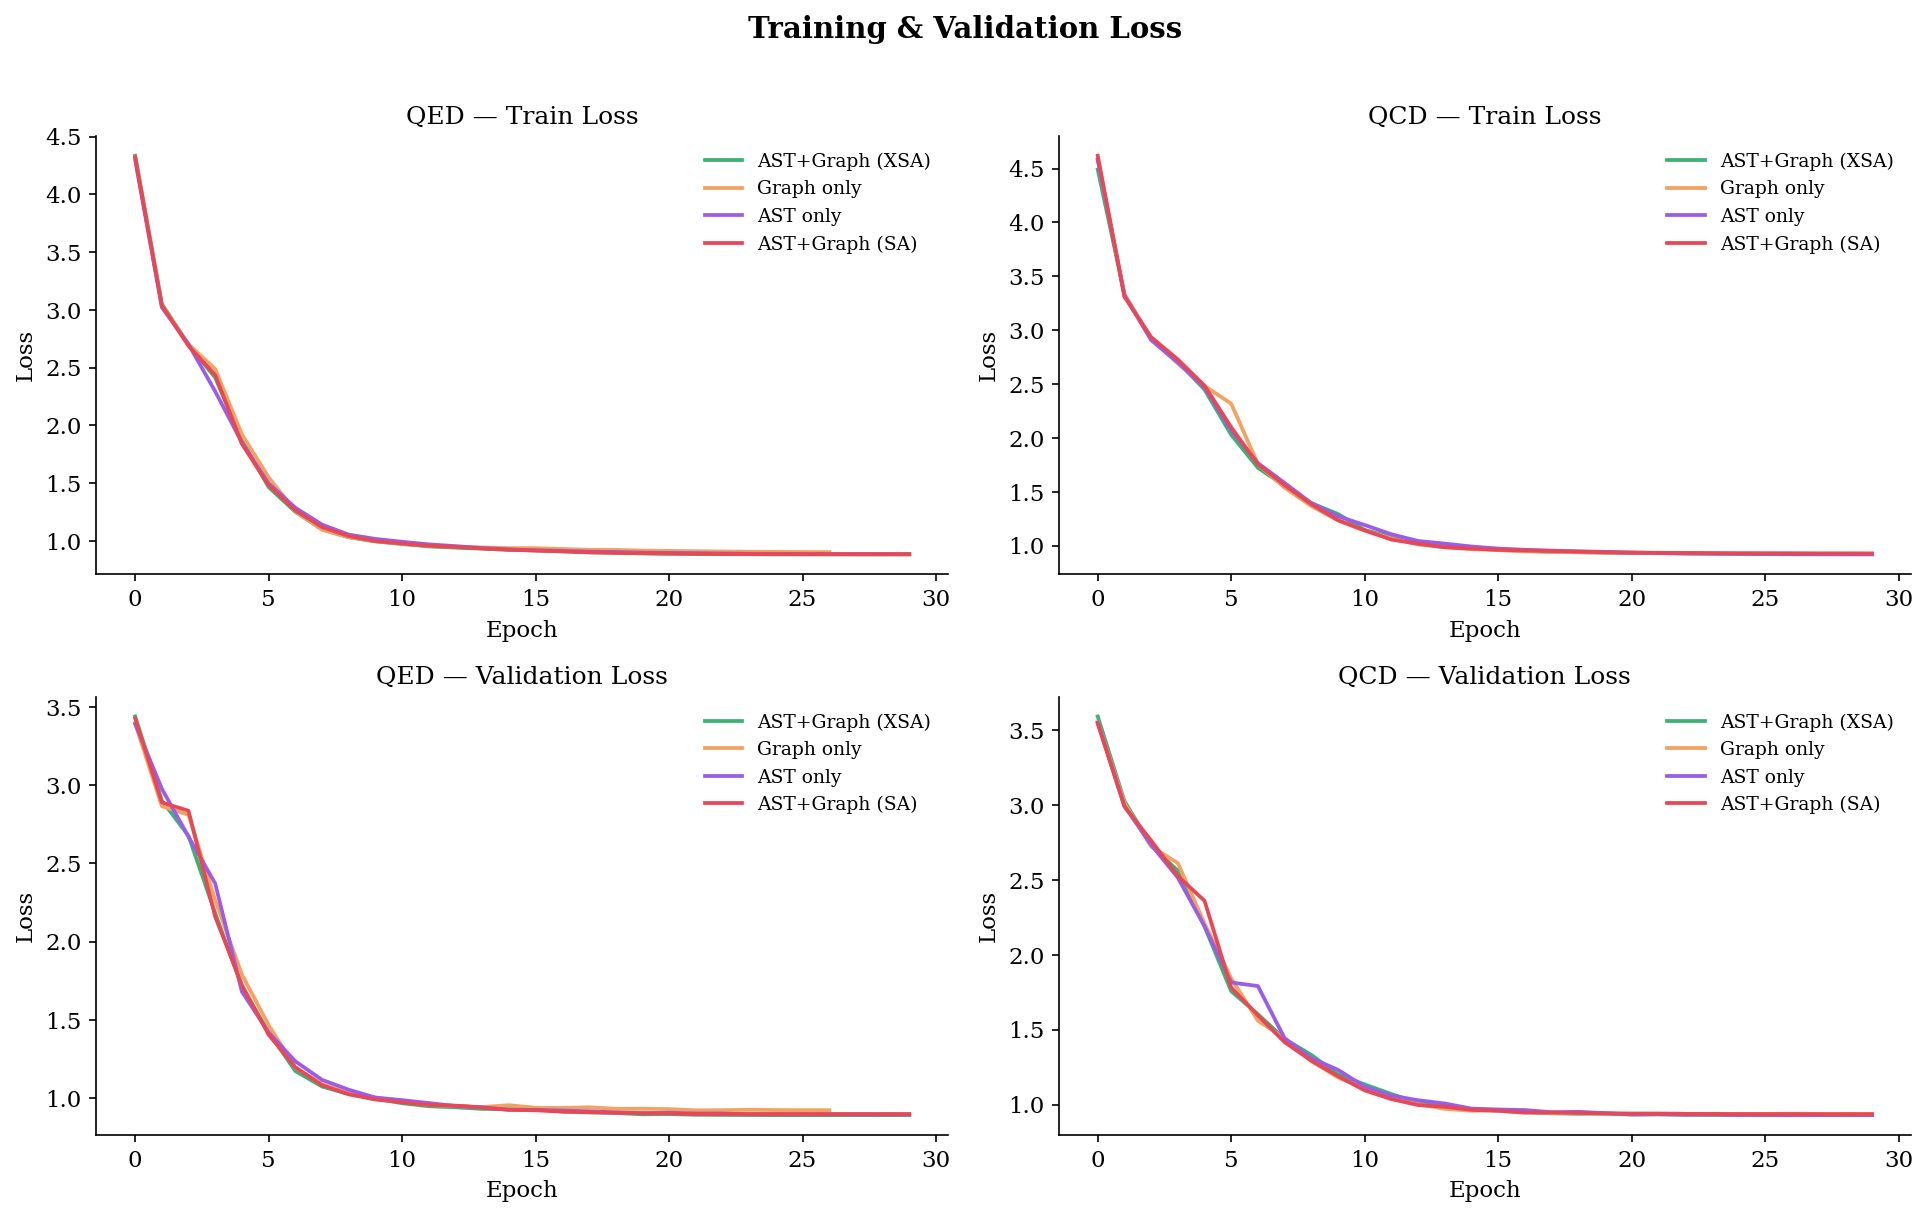

  Saved → proposal_figures/02_ablation_token_accuracy.png


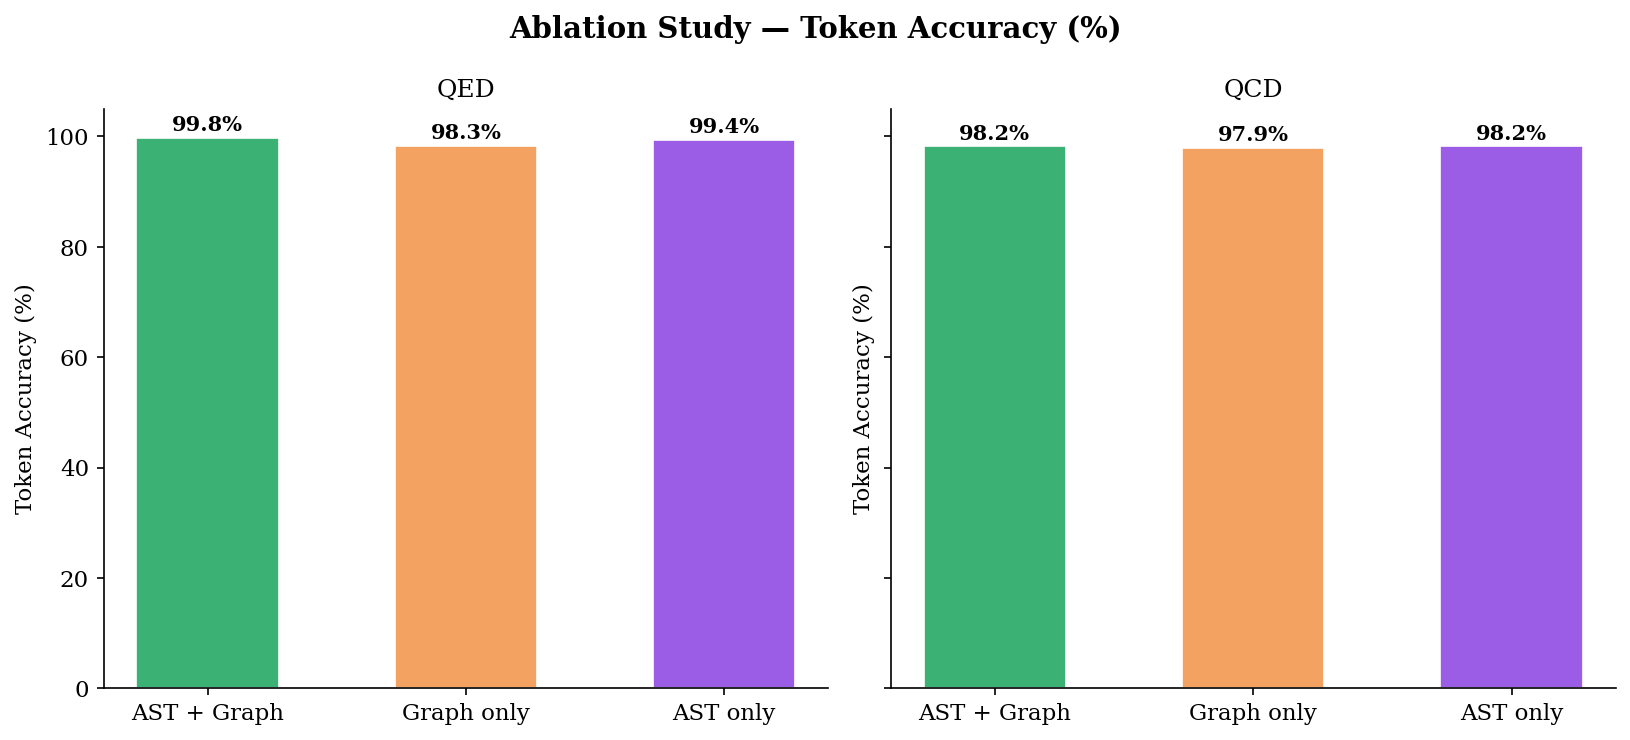

  Saved → proposal_figures/03_ablation_exact_match.png


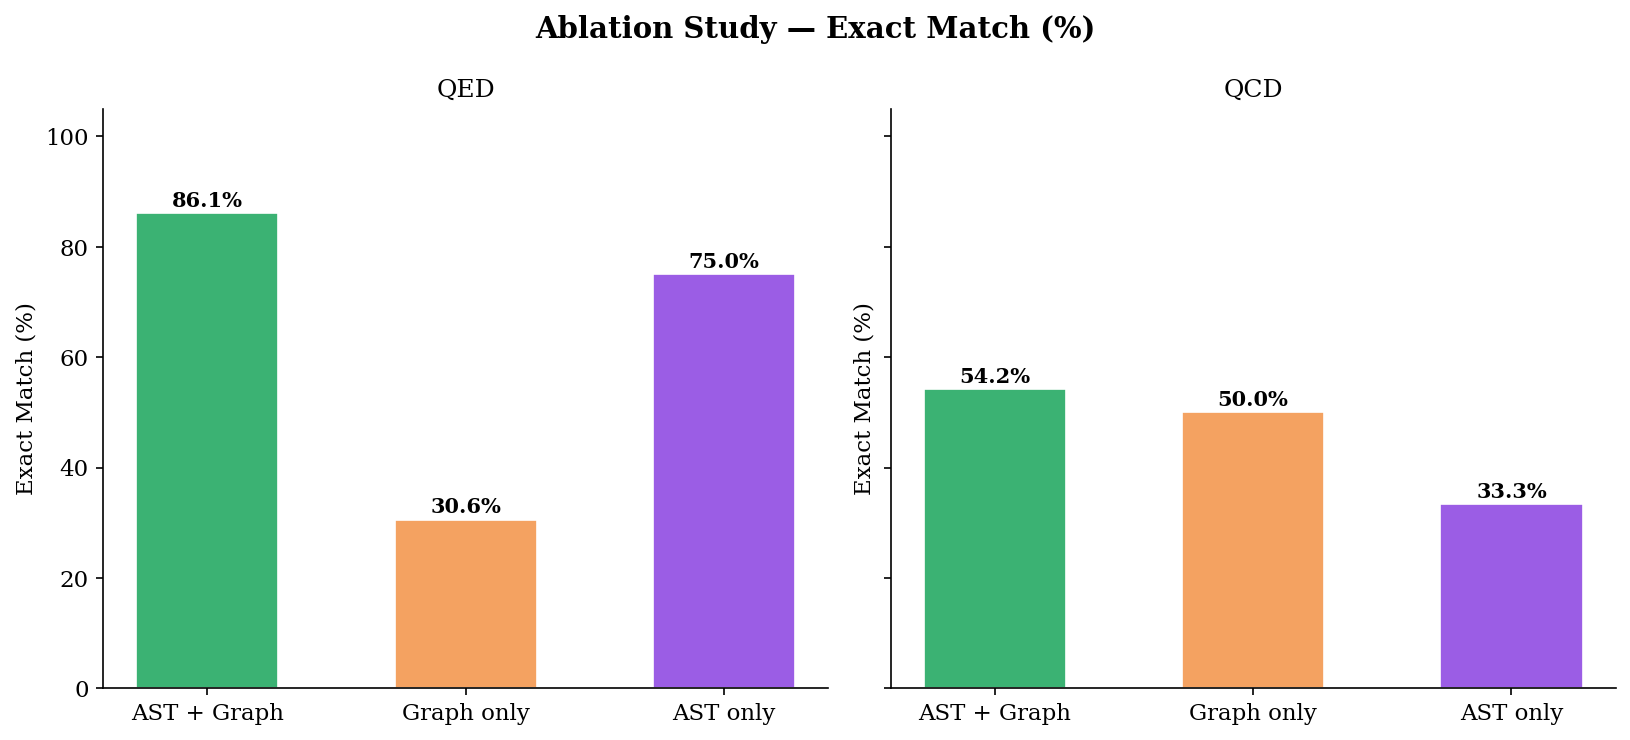

  Saved → proposal_figures/04_xsa_vs_sa.png


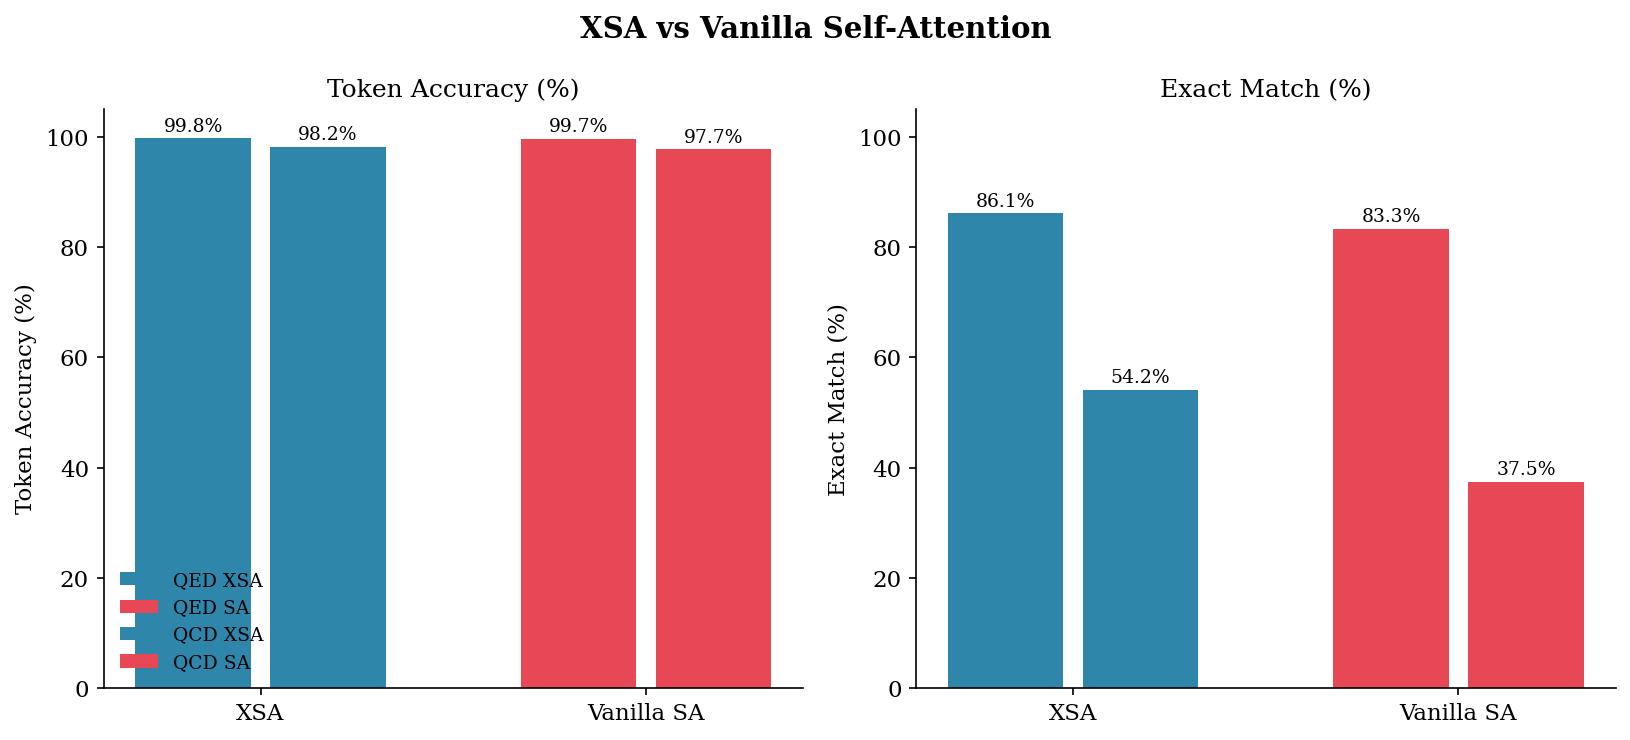

  Saved → proposal_figures/05_complexity_vs_error_scatter.png


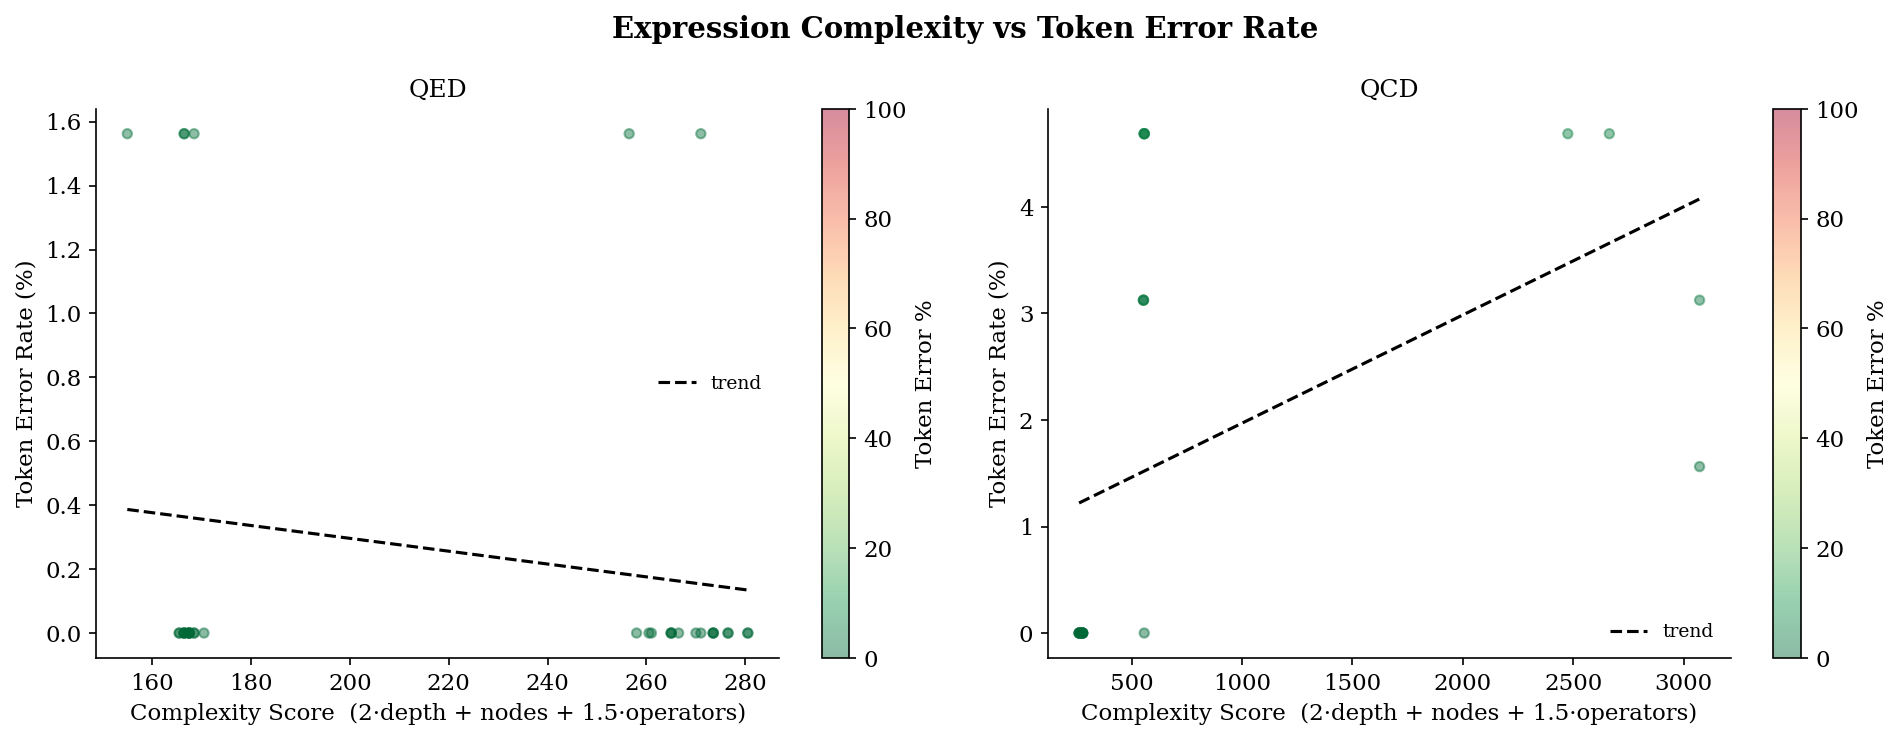

  Saved → proposal_figures/06_complexity_binned_exact_match.png


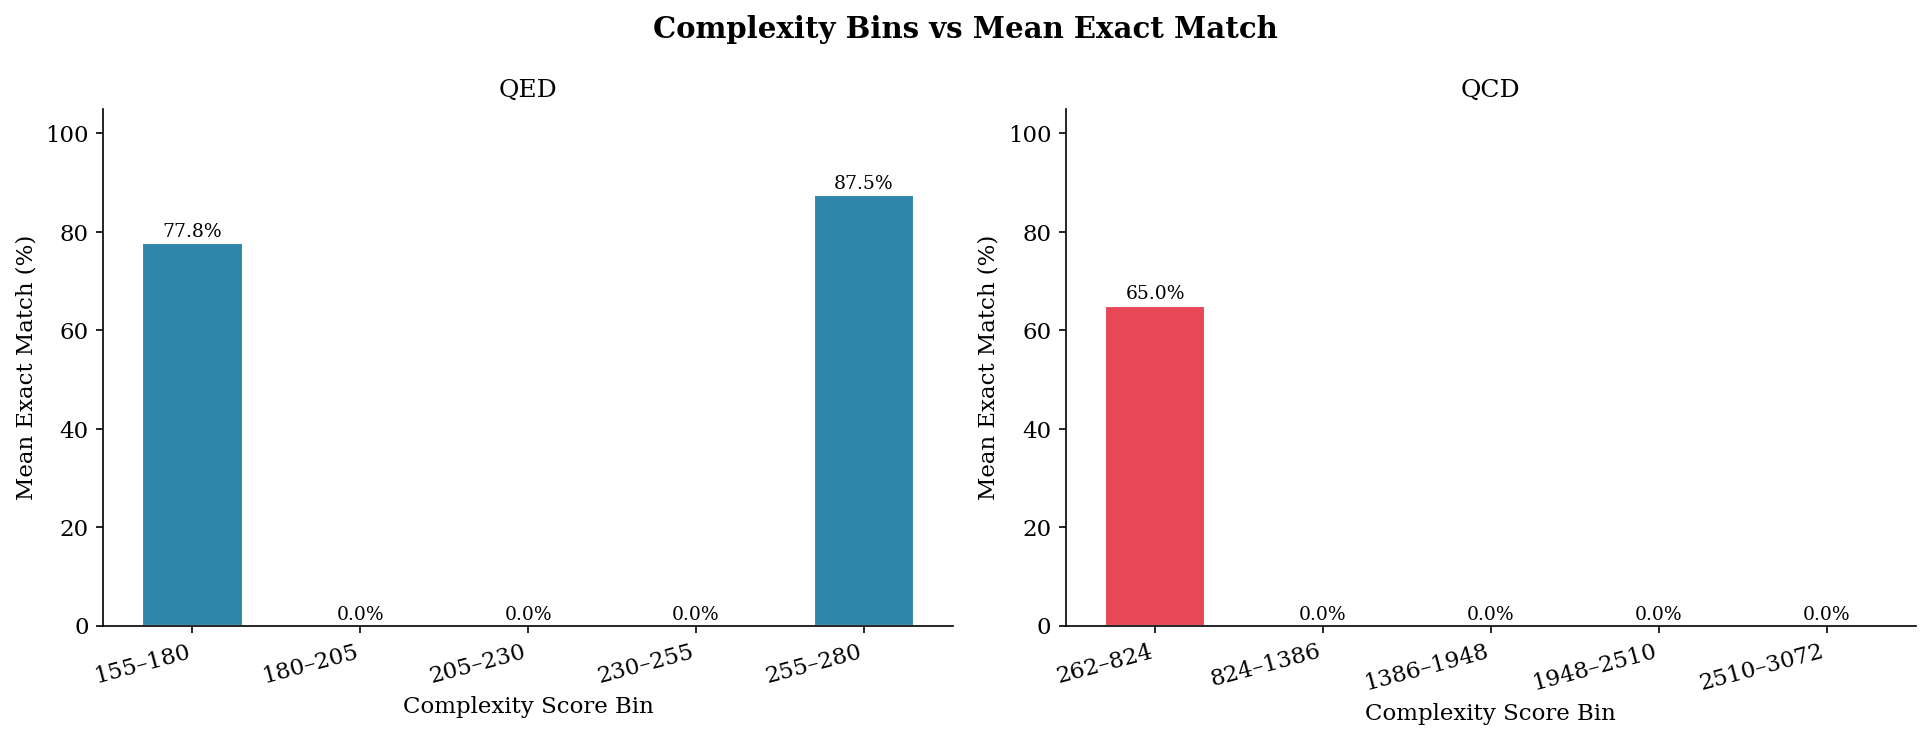

  Saved → proposal_figures/07_qed_heatmap.png


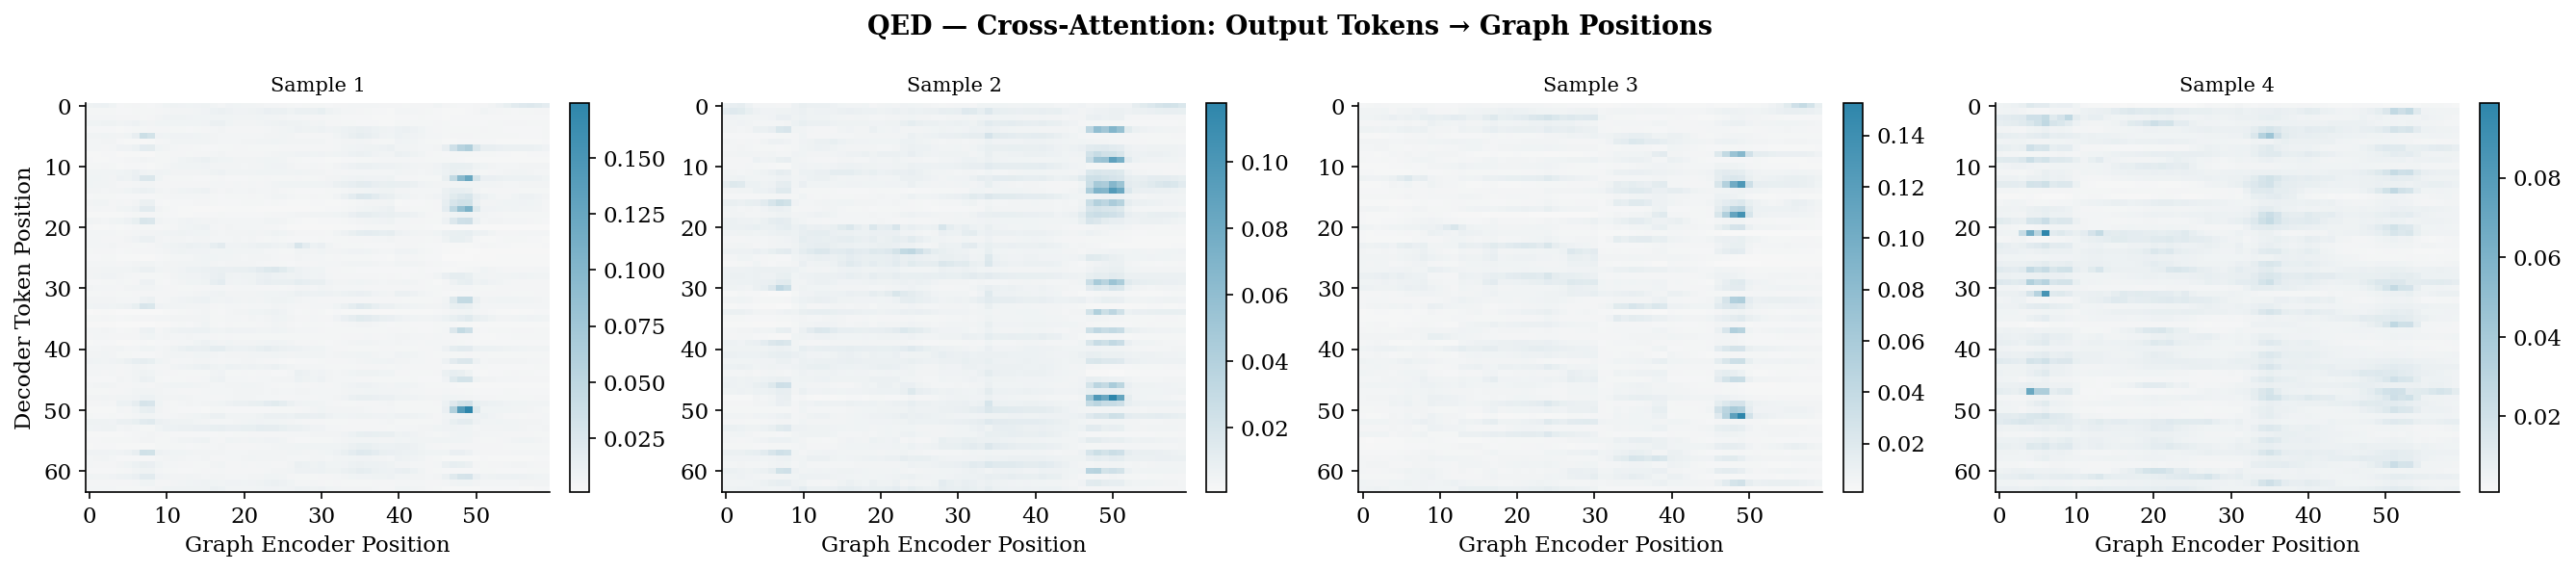

  Saved → proposal_figures/07_qcd_heatmap.png


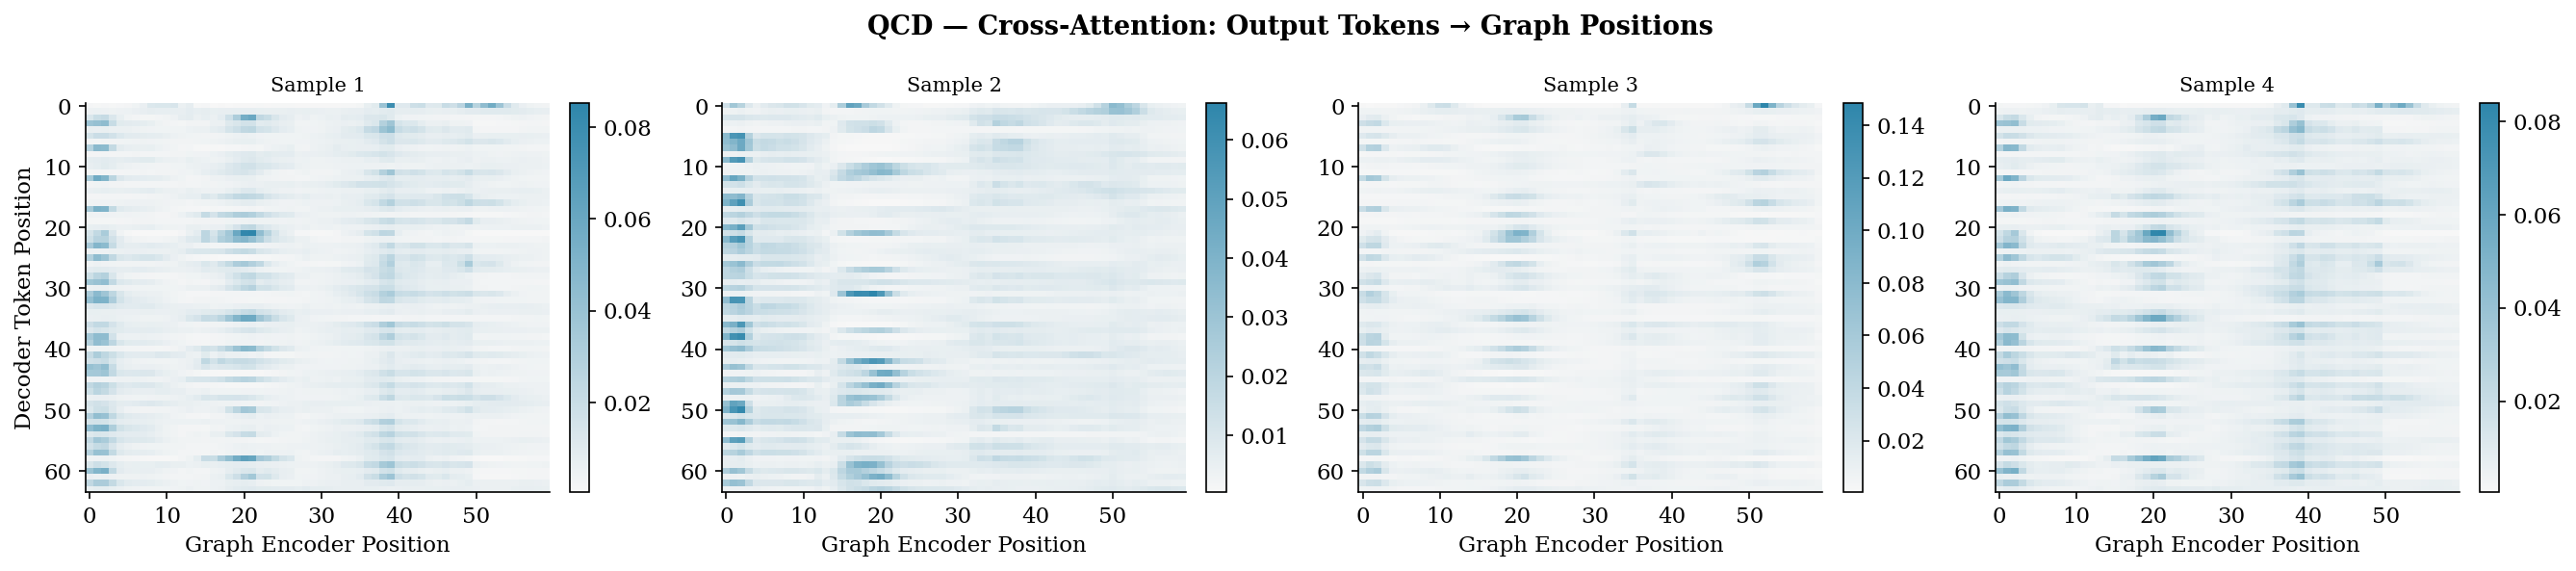

  Saved → proposal_figures/08_lr_schedule.png


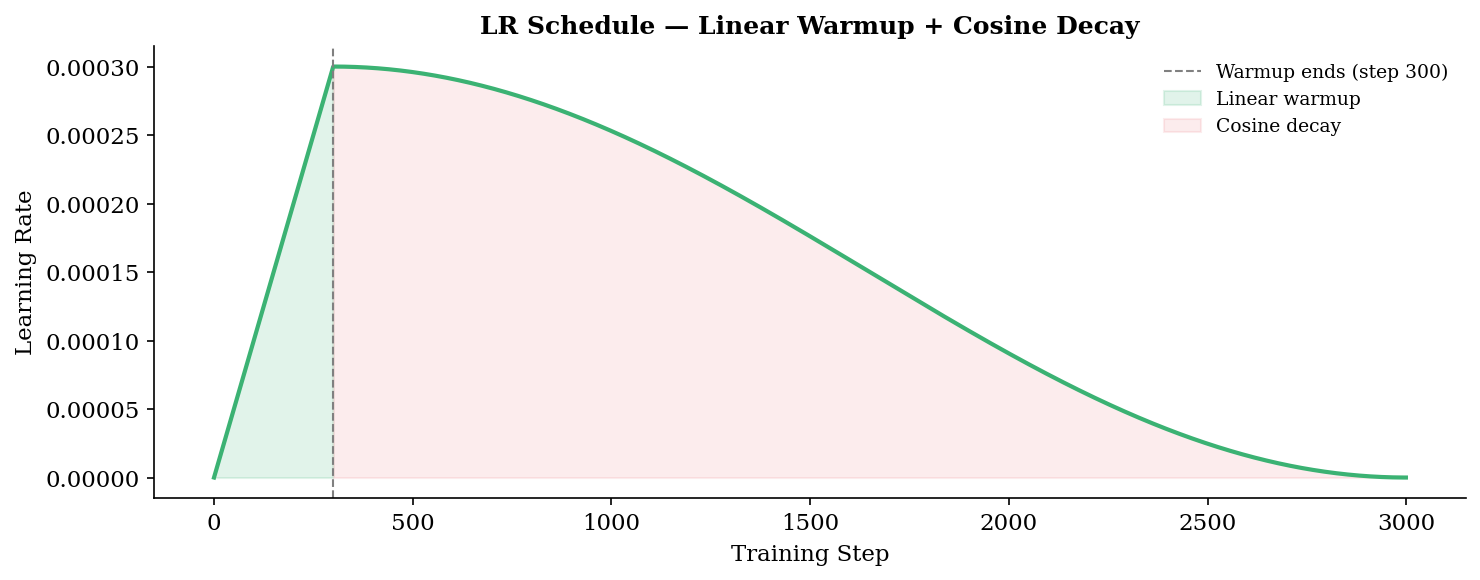


✅ All figures saved to 'proposal_figures/'
   Ready for proposal write-up.


In [ ]:
# ==========================================
# CELL 12: RESULTS VISUALISATION
# ==========================================
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import math
import os

# ── Style ───────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "font.size"        : 11,
    "axes.titlesize"   : 12,
    "axes.labelsize"   : 11,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "legend.frameon"   : False,
})

COLORS = {
    "qed"        : "#2E86AB",
    "qcd"        : "#E84855",
    "full"       : "#3BB273",
    "graph_only" : "#F4A261",
    "math_only"  : "#9B5DE5",
    "xsa"        : "#2E86AB",
    "sa"         : "#E84855",
}

SAVE_DIR = "proposal_figures"
os.makedirs(SAVE_DIR, exist_ok=True)

def save(fig, name):
    path = os.path.join(SAVE_DIR, f"{name}.png")
    fig.savefig(path, bbox_inches='tight')
    print(f"  Saved → {path}")


# ══════════════════════════════════════════════════════════════════════════════
# HELPER: safely pull a scalar list from history
# ══════════════════════════════════════════════════════════════════════════════

def get_history(run_name, key):
    return all_histories.get(run_name, {}).get(key, [])


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Loss Curves (Train & Val) for all runs
# ══════════════════════════════════════════════════════════════════════════════

def plot_loss_curves():
    run_groups = {
        "QED": ["QED_full_xsa", "QED_graph_only", "QED_math_only", "QED_full_sa"],
        "QCD": ["QCD_full_xsa", "QCD_graph_only", "QCD_math_only", "QCD_full_sa"],
    }
    labels = {
        "full_xsa"   : "AST+Graph (XSA)",
        "graph_only" : "Graph only",
        "math_only"  : "AST only",
        "full_sa"    : "AST+Graph (SA)",
    }
    line_colors = [COLORS["full"], COLORS["graph_only"],
                   COLORS["math_only"], COLORS["sa"]]

    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=False)
    fig.suptitle("Training & Validation Loss", fontsize=14, fontweight='bold', y=1.01)

    for col, (physics, runs) in enumerate(run_groups.items()):
        for row, split in enumerate(["train_loss", "val_loss"]):
            ax = axes[row][col]
            for run, color in zip(runs, line_colors):
                vals = get_history(run, split)
                if vals:
                    key = run.split("_", 1)[1]
                    ax.plot(vals, label=labels.get(key, key), color=color, linewidth=1.8)
            ax.set_title(f"{physics} — {'Train' if row == 0 else 'Validation'} Loss")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
            ax.legend(fontsize=9)

    fig.tight_layout()
    save(fig, "01_loss_curves")
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 & 3 — Superimposed Ablation Bars (Token Accuracy & Exact Match)
# ══════════════════════════════════════════════════════════════════════════════

def plot_ablation_bars():
    configs = [
        ("AST + Graph", "full_xsa",   COLORS["full"]),
        ("Graph only",  "graph_only", COLORS["graph_only"]),
        ("AST only",    "math_only",  COLORS["math_only"]),
    ]
    metrics = [
        ("token_accuracy", "Token Accuracy (%)",  "02_ablation_token_accuracy"),
        ("exact_match",    "Exact Match (%)",      "03_ablation_exact_match"),
    ]

    for metric_key, ylabel, fname in metrics:
        fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
        fig.suptitle(f"Ablation Study — {ylabel}", fontsize=14, fontweight='bold')

        x      = np.arange(len(configs))
        width  = 0.55

        for col, physics in enumerate(["QED", "QCD"]):
            ax     = axes[col]
            values = []
            for _, suffix, _ in configs:
                run  = f"{physics}_{suffix}"
                hist = get_history(run, metric_key)
                values.append(max(hist) * 100 if hist else 0.0)

            bars = ax.bar(
                x, values,
                width=width,
                color=[c for _, _, c in configs],
                edgecolor='white', linewidth=0.8,
            )

            # Value labels on bars
            for bar, val in zip(bars, values):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f"{val:.1f}%",
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                )

            ax.set_title(physics)
            ax.set_xticks(x)
            ax.set_xticklabels([label for label, _, _ in configs])
            ax.set_ylabel(ylabel)
            ax.set_ylim(0, 105)

        fig.tight_layout()
        save(fig, fname)
        plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — XSA vs Vanilla SA
# ══════════════════════════════════════════════════════════════════════════════

def plot_xsa_vs_sa():
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    fig.suptitle("XSA vs Vanilla Self-Attention", fontsize=14, fontweight='bold')

    metrics = [("token_accuracy", "Token Accuracy (%)"),
               ("exact_match",    "Exact Match (%)")]

    for col, (metric_key, ylabel) in enumerate(metrics):
        ax    = axes[col]
        x     = np.arange(2)
        width = 0.3

        for offset, physics in enumerate(["QED", "QCD"]):
            xsa_hist = get_history(f"{physics}_full_xsa", metric_key)
            sa_hist  = get_history(f"{physics}_full_sa",  metric_key)
            xsa_val  = max(xsa_hist) * 100 if xsa_hist else 0.0
            sa_val   = max(sa_hist)  * 100 if sa_hist  else 0.0

            pos = x + offset * (width + 0.05)
            ax.bar(pos[0], xsa_val, width, color=COLORS["xsa"],
                   label=f"{physics} XSA" if col == 0 else "_nolegend_")
            ax.bar(pos[1], sa_val,  width, color=COLORS["sa"],
                   label=f"{physics} SA"  if col == 0 else "_nolegend_")

            for xp, val in zip(pos, [xsa_val, sa_val]):
                ax.text(xp, val + 0.5, f"{val:.1f}%",
                        ha='center', va='bottom', fontsize=9)

        ax.set_xticks(x + width / 2 + 0.025)
        ax.set_xticklabels(["XSA", "Vanilla SA"])
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.set_ylim(0, 105)
        if col == 0:
            ax.legend(fontsize=9)

    fig.tight_layout()
    save(fig, "04_xsa_vs_sa")
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 5 — Complexity vs Token Error (scatter)
# ══════════════════════════════════════════════════════════════════════════════

def plot_complexity_scatter():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Expression Complexity vs Token Error Rate",
                 fontsize=14, fontweight='bold')

    for col, physics in enumerate(["QED", "QCD"]):
        ax   = axes[col]
        run  = f"{physics}_full_xsa"
        hist = all_histories.get(run, {}).get('complexity_results', [])

        if not hist:
            ax.set_title(f"{physics} — no data")
            continue

        # Use the last epoch's results
        epoch_results = hist[-1]
        complexities  = [r['complexity']  for r in epoch_results]
        errors        = [r['token_error'] * 100 for r in epoch_results]

        # Scatter with colour-coded density
        sc = ax.scatter(complexities, errors,
                        alpha=0.45, s=20,
                        c=errors, cmap='RdYlGn_r', vmin=0, vmax=100)
        plt.colorbar(sc, ax=ax, label="Token Error %")

        # Trend line
        if len(complexities) > 2:
            z   = np.polyfit(complexities, errors, 1)
            p   = np.poly1d(z)
            xs  = np.linspace(min(complexities), max(complexities), 200)
            ax.plot(xs, p(xs), color='black', linewidth=1.5,
                    linestyle='--', label='trend')

        ax.set_xlabel("Complexity Score  (2·depth + nodes + 1.5·operators)")
        ax.set_ylabel("Token Error Rate (%)")
        ax.set_title(physics)
        ax.legend(fontsize=9)

    fig.tight_layout()
    save(fig, "05_complexity_vs_error_scatter")
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 6 — Complexity vs Exact Match (binned bar chart)
# ══════════════════════════════════════════════════════════════════════════════

def plot_complexity_binned():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Complexity Bins vs Mean Exact Match",
                 fontsize=14, fontweight='bold')

    for col, physics in enumerate(["QED", "QCD"]):
        ax   = axes[col]
        run  = f"{physics}_full_xsa"
        hist = all_histories.get(run, {}).get('complexity_results', [])

        if not hist:
            ax.set_title(f"{physics} — no data")
            continue

        epoch_results = hist[-1]
        complexities  = np.array([r['complexity']  for r in epoch_results])
        matches       = np.array([r['exact_match'] for r in epoch_results])

        # Bin into 5 equal-width buckets
        n_bins    = 5
        bin_edges = np.linspace(complexities.min(), complexities.max(), n_bins + 1)
        bin_means, bin_labels = [], []

        for i in range(n_bins):
            mask = (complexities >= bin_edges[i]) & (complexities < bin_edges[i + 1])
            bin_means.append(matches[mask].mean() * 100 if mask.sum() > 0 else 0.0)
            lo = f"{bin_edges[i]:.0f}"
            hi = f"{bin_edges[i+1]:.0f}"
            bin_labels.append(f"{lo}–{hi}")

        bars = ax.bar(range(n_bins), bin_means,
                      color=COLORS["qed" if physics == "QED" else "qcd"],
                      edgecolor='white', width=0.6)

        for bar, val in zip(bars, bin_means):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f"{val:.1f}%", ha='center', va='bottom', fontsize=9)

        ax.set_xticks(range(n_bins))
        ax.set_xticklabels(bin_labels, rotation=15, ha='right')
        ax.set_xlabel("Complexity Score Bin")
        ax.set_ylabel("Mean Exact Match (%)")
        ax.set_title(physics)
        ax.set_ylim(0, 105)

    fig.tight_layout()
    save(fig, "06_complexity_binned_exact_match")
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 7 — Graph Attention Heatmap (Test 2)
# ══════════════════════════════════════════════════════════════════════════════

def plot_heatmaps(device):
    for physics in ["QED", "QCD"]:
        run_name = f"{physics}_full_xsa"

        # Load best checkpoint
        ckpt_path = os.path.join(SAVE_DIR.replace("proposal_figures", "checkpoints"),
                                 f"{run_name}_best.pt")
        if not os.path.exists(ckpt_path):
            print(f"  ⚠️  Checkpoint not found for {run_name}, skipping heatmap.")
            continue

        model = FeynmanModel().to(device)
        model.load_state_dict(torch.load(ckpt_path, map_location=device)['model_state_dict'])

        train_key = f"{physics.lower()}_train"
        loader    = feynman_loaders.get(train_key)
        if loader is None:
            continue

        heatmap = get_graph_heatmap(model, loader, device, num_samples=4)
        if heatmap is None:
            continue

        # heatmap shape: (4, target_len, graph_len)
        fig, axes = plt.subplots(1, 4, figsize=(18, 4))
        fig.suptitle(f"{physics} — Cross-Attention: Output Tokens → Graph Positions",
                     fontsize=13, fontweight='bold')

        cmap = LinearSegmentedColormap.from_list(
            "attn", ["#f7f7f7", "#2E86AB"], N=256
        )

        for i, ax in enumerate(axes):
            im = ax.imshow(
                heatmap[i].numpy(),
                aspect='auto', cmap=cmap,
                interpolation='nearest',
            )
            ax.set_title(f"Sample {i+1}", fontsize=10)
            ax.set_xlabel("Graph Encoder Position")
            ax.set_ylabel("Decoder Token Position" if i == 0 else "")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        fig.tight_layout()
        save(fig, f"07_{physics.lower()}_heatmap")
        plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 8 — LR Schedule Visualisation
# ══════════════════════════════════════════════════════════════════════════════

def plot_lr_schedule():
    num_epochs      = NUM_EPOCHS
    steps_per_epoch = 100          # approximate; adjust to your actual loader size
    total_steps     = num_epochs * steps_per_epoch
    warmup_steps    = int(0.10 * total_steps)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    steps = np.arange(total_steps)
    lrs   = [3e-4 * lr_lambda(s) for s in steps]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(steps, lrs, color=COLORS["full"], linewidth=2)
    ax.axvline(warmup_steps, color='grey', linestyle='--', linewidth=1,
               label=f"Warmup ends (step {warmup_steps})")
    ax.fill_between(steps[:warmup_steps], lrs[:warmup_steps],
                    alpha=0.15, color=COLORS["full"], label="Linear warmup")
    ax.fill_between(steps[warmup_steps:], lrs[warmup_steps:],
                    alpha=0.10, color=COLORS["qcd"],  label="Cosine decay")
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Learning Rate")
    ax.set_title("LR Schedule — Linear Warmup + Cosine Decay", fontweight='bold')
    ax.legend(fontsize=9)
    fig.tight_layout()
    save(fig, "08_lr_schedule")
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# RUN ALL PLOTS
# ══════════════════════════════════════════════════════════════════════════════

print("Generating proposal figures ...\n")
plot_loss_curves()
plot_ablation_bars()
plot_xsa_vs_sa()
plot_complexity_scatter()
plot_complexity_binned()
plot_heatmaps(device)
plot_lr_schedule()

print(f"\n✅ All figures saved to '{SAVE_DIR}/'")
print("   Ready for proposal write-up.")

In [ ]:
# ==========================================
# CELL 12 ADDITION: BEAM SEARCH & DECODE-THEN-COMPARE
# ==========================================
# Drop this in AFTER Cell 11 training is complete.
# No retraining required — inference-time only changes.
# ==========================================
import torch
import torch.nn.functional as F

# ── Config ─────────────────────────────────────────────────────────────────────
BEAM_WIDTH  = 4
MAX_GEN_LEN = 65      # must match MAX_TARGET_LEN from Cell 10
BYTE_OFFSET = 4
SOS_IDX     = 1
EOS_IDX     = 2
PAD_IDX     = 0
# ───────────────────────────────────────────────────────────────────────────────


# ══════════════════════════════════════════════════════════════════════════════
# BYTE DECODER  — converts predicted tensor back to a string
# ══════════════════════════════════════════════════════════════════════════════

def decode_bytes_to_str(token_ids: list) -> str:
    """
    Converts a list of integer token IDs back to a Python string.
    Stops at EOS. Skips PAD, SOS, UNK (IDs 0-3).
    IDs 4-259 map back to UTF-8 bytes 0-255.
    """
    byte_vals = []
    for tok in token_ids:
        if tok == EOS_IDX:
            break
        if tok < BYTE_OFFSET:   # PAD / SOS / EOS / UNK
            continue
        byte_vals.append(tok - BYTE_OFFSET)
    try:
        return bytes(byte_vals).decode('utf-8', errors='replace')
    except Exception:
        return ""


# ══════════════════════════════════════════════════════════════════════════════
# DUMMY INDEX NORMALISER  — physics-aware string canonicalisation
# ══════════════════════════════════════════════════════════════════════════════

def normalise_dummy_indices(expression: str) -> str:
    """
    Renames dummy indices in order of first appearance so that
    mathematically equivalent expressions with different index labels
    (e.g. mu_d1 vs mu_d2) compare as equal.

    This is the same logic as perfect_standardizer() in Cell 2,
    applied to decoded prediction strings before comparison.
    """
    import re
    mapping, counter = {}, [1]

    def replacer(match):
        prefix, idx = match.group(1), match.group(2)
        if idx not in mapping:
            mapping[idx] = f"d{counter[0]}"
            counter[0] += 1
        return f"{prefix}{mapping[idx]}"

    return re.sub(r'(%[a-zA-Z\\]+_)(d\d+)', replacer, expression)


# ══════════════════════════════════════════════════════════════════════════════
# BEAM SEARCH DECODER
# ══════════════════════════════════════════════════════════════════════════════

def beam_search_decode(
    model,
    graph_tensor: torch.Tensor,
    math_tensor:  torch.Tensor,
    device: torch.device,
    beam_width: int = BEAM_WIDTH,
    max_len:    int = MAX_GEN_LEN,
) -> list:
    """
    Runs beam search for a SINGLE sample (no batch dimension).

    Args:
        graph_tensor : (MAX_GRAPH_LEN,)  — single graph byte sequence
        math_tensor  : (MAX_MATH_LEN,)   — single math  byte sequence
        device       : torch device

    Returns:
        best_sequence : list[int]  — predicted token IDs (best beam)
    """
    model.eval()

    # Add batch dimension → (1, L)
    graph = graph_tensor.unsqueeze(0).to(device)
    math_ = math_tensor.unsqueeze(0).to(device)

    # Pre-compute encoder outputs (done once, reused for all beams)
    with torch.no_grad():
        g_emb = model.gbst_graph(graph)
        m_emb = model.gbst_math(math_)
        g_enc, m_enc = model.encoders(g_emb, m_emb)
        memory, graph_len = model.decoder._build_memory(g_enc, m_enc, device, 1)

    # Each beam: (sequence_so_far, cumulative_log_prob)
    beams = [([SOS_IDX], 0.0)]

    for step in range(max_len - 1):
        all_candidates = []

        for seq, score in beams:
            # If this beam already ended, carry it forward unchanged
            if seq[-1] == EOS_IDX:
                all_candidates.append((seq, score))
                continue

            # Forward pass through the decoder with current sequence
            decoder_input = torch.tensor([seq], dtype=torch.long, device=device)

            with torch.no_grad():
                x = model.decoder.pos_encoder(model.decoder.embedding(decoder_input))
                for layer in model.decoder.layers:
                    x, _ = layer(x, memory, return_attn_weights=False,
                                 graph_len=graph_len)
                logits = model.decoder.fc_out(x)            # (1, step+1, vocab)

            # Take logits at the last position
            last_logits = logits[0, -1, :]                  # (vocab,)
            log_probs   = F.log_softmax(last_logits, dim=-1)

            # Expand: take top beam_width tokens
            top_log_probs, top_tokens = log_probs.topk(beam_width)

            for log_p, tok in zip(top_log_probs.tolist(), top_tokens.tolist()):
                all_candidates.append((seq + [tok], score + log_p))

        # Keep the top beam_width candidates by score
        beams = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_width]

        # Early exit if all beams have ended
        if all(seq[-1] == EOS_IDX for seq, _ in beams):
            break

    # Return the highest-scoring sequence
    return beams[0][0]


# ══════════════════════════════════════════════════════════════════════════════
# FULL EVALUATION WITH BEAM SEARCH + DECODE-THEN-COMPARE
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_with_beam_search(
    model,
    loader,
    device,
    beam_width: int = BEAM_WIDTH,
    max_samples: int = None,   # set to small number for quick testing
) -> dict:
    """
    Runs beam search on the validation set and computes:
        1. Greedy exact match   (byte-level, fast baseline)
        2. Beam exact match     (byte-level, beam_width beams)
        3. Symbolic exact match (after decode + dummy index normalisation)

    Returns a dict of metric lists (one value per sample).
    """
    model.eval()

    results = {
        'greedy_exact'   : [],
        'beam_exact'     : [],
        'symbolic_exact' : [],
    }

    total = 0

    for graph_batch, math_batch, target_batch, _ in loader:
        for i in range(graph_batch.size(0)):
            if max_samples and total >= max_samples:
                break

            graph_t  = graph_batch[i]
            math_t   = math_batch[i]
            target_t = target_batch[i]

            # Ground truth string (decoded from byte tensor)
            gt_ids  = target_t[1:].tolist()  # skip SOS
            gt_str  = decode_bytes_to_str(gt_ids)
            gt_norm = normalise_dummy_indices(gt_str)

            # ── 1. Greedy decoding ─────────────────────────────────────────
            with torch.no_grad():
                logits, _ = model(
                    graph_t.unsqueeze(0).to(device),
                    math_t.unsqueeze(0).to(device),
                    target_t[:-1].unsqueeze(0).to(device),   # teacher forced
                )
            greedy_ids = logits[0].argmax(dim=-1).tolist()
            greedy_str = decode_bytes_to_str(greedy_ids)

            # ── 2. Beam search decoding ────────────────────────────────────
            beam_ids = beam_search_decode(model, graph_t, math_t, device, beam_width)
            beam_str = decode_bytes_to_str(beam_ids[1:])  # skip SOS

            # ── 3. Symbolic comparison (normalise dummy indices first) ──────
            beam_norm   = normalise_dummy_indices(beam_str)
            greedy_norm = normalise_dummy_indices(greedy_str)

            results['greedy_exact'].append(int(greedy_str == gt_str))
            results['beam_exact'].append(int(beam_str   == gt_str))
            results['symbolic_exact'].append(int(beam_norm == gt_norm))

            total += 1

        if max_samples and total >= max_samples:
            break

    n = max(1, total)
    summary = {k: sum(v) / n * 100 for k, v in results.items()}
    return summary, results


# ══════════════════════════════════════════════════════════════════════════════
# EXECUTION — run on best checkpoints for QED and QCD
# ══════════════════════════════════════════════════════════════════════════════

print("Running Beam Search Evaluation on best checkpoints...\n")
print("=" * 60)

beam_results_all = {}

for physics in ["QED", "QCD"]:
    run_name  = f"{physics}_full_xsa"
    ckpt_path = os.path.join("checkpoints", f"{run_name}_best.pt")
    loader    = feynman_loaders[f"{physics.lower()}_test"]

    if not os.path.exists(ckpt_path) or loader is None:
        print(f"  ⚠️  Skipping {physics} — checkpoint or loader missing.")
        continue

    # Load best model
    eval_model = FeynmanModel().to(device)
    eval_model.load_state_dict(
        torch.load(ckpt_path, map_location=device)['model_state_dict']
    )

    print(f"  [{physics}] Running beam search (width={BEAM_WIDTH})...")
    summary, raw = evaluate_with_beam_search(
        eval_model, loader, device,
        beam_width=BEAM_WIDTH,
        max_samples=None,     # set e.g. 100 for a quick test run
    )
    beam_results_all[physics] = summary

    print(f"  [{physics}] Results:")
    print(f"    Greedy exact match   : {summary['greedy_exact']:.1f}%")
    print(f"    Beam exact match     : {summary['beam_exact']:.1f}%")
    print(f"    Symbolic exact match : {summary['symbolic_exact']:.1f}%  "
          f"(after dummy index normalisation)")
    print()

print("=" * 60)
print("\n✅ Beam search evaluation complete.")
print("   'symbolic_exact' is your most meaningful metric for the proposal.")
print("   Compare 'greedy_exact' vs 'beam_exact' to quantify beam search gain.")